# DEAL UPGRADE

### Import Libraries

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
import warnings
warnings.filterwarnings('ignore')

# Import visualization libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


### Load Raw Data - Deal Upgrade Site

In [2]:
# Load the raw site data
site_data_path = '../data/fathom_deal_upgrade_site.csv'

# Check if file exists
if not os.path.exists(site_data_path):
    print(f"❌ Error: File not found at {site_data_path}")
    print("Please make sure the file exists in the data folder.")
else:
    # Read the CSV file
    df_site_raw = pd.read_csv(site_data_path)
    
    print("✓ Deal Upgrade Site data loaded successfully")
    print(f"\nDataset shape: {df_site_raw.shape[0]} rows × {df_site_raw.shape[1]} columns")
    print(f"\nFirst few rows:")
    display(df_site_raw.head(5))

✓ Deal Upgrade Site data loaded successfully

Dataset shape: 2119 rows × 5 columns

First few rows:


,Timestamp,Pageviews,Visits,Avg Duration,Bounce Rate
0,2025-07-07 04:00:00,1,1,NaN,1.00
1,2025-10-24 19:00:00,8,6,558.00,0.83
2,2025-08-23 11:00:00,1,1,NaN,1.00
3,2025-10-04 02:00:00,1,1,NaN,1.00
4,2025-07-15 02:00:00,3,2,24.00,0.50


### Load Raw Data - Deal Upgrade Events

In [3]:
# Load the raw events data
events_data_path = '../data/fathom_deal_upgrade_events.csv'

# Check if file exists
if not os.path.exists(events_data_path):
    print(f"❌ Error: File not found at {events_data_path}")
    print("Please make sure the file exists in the data folder.")
else:
    # Read the CSV file
    df_events_raw = pd.read_csv(events_data_path)
    
    print("✓ Deal Upgrade Events data loaded successfully")
    print(f"\nDataset shape: {df_events_raw.shape[0]} rows × {df_events_raw.shape[1]} columns")
    print(f"\nFirst few rows:")
    display(df_events_raw.head(5))

✓ Deal Upgrade Events data loaded successfully

Dataset shape: 1330 rows × 5 columns

First few rows:


,Timestamp,Event Name,Event Code,Completions,Value
0,2025-11-15 18:00:00,Learn More,2256890a-8105-457b-b2dd-6c638345cefe,1,0
1,2025-07-10 21:00:00,Learn More,2256890a-8105-457b-b2dd-6c638345cefe,7,0
2,2025-07-15 19:00:00,Learn More,2256890a-8105-457b-b2dd-6c638345cefe,4,0
3,2025-11-28 15:00:00,Learn More,2256890a-8105-457b-b2dd-6c638345cefe,3,0
4,2025-07-22 19:00:00,Learn More,2256890a-8105-457b-b2dd-6c638345cefe,9,0


### Inspect Site Data Structure

In [4]:
# Display site data info
print("Deal Upgrade Site Data Information:")
print("=" * 60)
df_site_raw.info()

print("\n" + "=" * 60)
print("Missing Values Check:")
print("=" * 60)
missing = df_site_raw.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found")
else:
    print(missing[missing > 0])

print("\n" + "=" * 60)
print("Basic Statistics:")
print("=" * 60)
display(df_site_raw.describe())

Deal Upgrade Site Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2119 entries, 0 to 2118
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Timestamp     2119 non-null   object 
 1   Pageviews     2119 non-null   int64  
 2   Visits        2119 non-null   int64  
 3   Avg Duration  540 non-null    float64
 4   Bounce Rate   2079 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 82.9+ KB

Missing Values Check:
Avg Duration    1579
Bounce Rate       40
dtype: int64

Basic Statistics:


,Pageviews,Visits,Avg Duration,Bounce Rate
count,2119.00,2119.00,540.00,2079.00
mean,3.48,2.95,186.56,0.87
std,5.95,5.10,290.86,0.28
min,1.00,0.00,1.00,0.00
25%,1.00,1.00,24.00,0.95
50%,2.00,1.00,67.62,1.00
75%,3.00,3.00,206.12,1.00
max,74.00,58.00,1799.00,1.00


### Inspect Events Data Structure

In [5]:
# Display events data info
print("Deal Upgrade Events Data Information:")
print("=" * 60)
df_events_raw.info()

print("\n" + "=" * 60)
print("Missing Values Check:")
print("=" * 60)
missing = df_events_raw.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found")
else:
    print(missing[missing > 0])

print("\n" + "=" * 60)
print("Basic Statistics:")
print("=" * 60)
display(df_events_raw.describe())

Deal Upgrade Events Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Timestamp    1330 non-null   object
 1   Event Name   1330 non-null   object
 2   Event Code   1330 non-null   object
 3   Completions  1330 non-null   int64 
 4   Value        1330 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.1+ KB

Missing Values Check:
✓ No missing values found

Basic Statistics:


,Completions,Value
count,1330.00,1330.00
mean,2.41,0.00
std,3.27,0.00
min,1.00,0.00
25%,1.00,0.00
50%,1.00,0.00
75%,2.00,0.00
max,29.00,0.00


### Process Site Data - Extract Date and Aggregate Daily

In [6]:
# Create a working copy of site data
df_site = df_site_raw.copy()

# Convert timestamp to datetime
df_site['Timestamp'] = pd.to_datetime(df_site['Timestamp'])

# Extract just the date (remove time component)
df_site['Date'] = df_site['Timestamp'].dt.date

print("✓ Site timestamp processed successfully")
print(f"\nDate range in site dataset:")
print(f"  Earliest: {df_site['Date'].min()}")
print(f"  Latest: {df_site['Date'].max()}")
print(f"  Total days: {(df_site['Date'].max() - df_site['Date'].min()).days + 1} days")

print(f"\nSample of processed site data:")
display(df_site[['Timestamp', 'Date', 'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate']].head(5))

✓ Site timestamp processed successfully

Date range in site dataset:
  Earliest: 2025-06-16
  Latest: 2025-12-08
  Total days: 176 days

Sample of processed site data:


,Timestamp,Date,Pageviews,Visits,Avg Duration,Bounce Rate
0,2025-07-07 04:00:00,2025-07-07,1,1,NaN,1.00
1,2025-10-24 19:00:00,2025-10-24,8,6,558.00,0.83
2,2025-08-23 11:00:00,2025-08-23,1,1,NaN,1.00
3,2025-10-04 02:00:00,2025-10-04,1,1,NaN,1.00
4,2025-07-15 02:00:00,2025-07-15,3,2,24.00,0.50


### Create Daily Site Data

In [7]:
# Group by date and aggregate site metrics
df_site_daily = df_site.groupby('Date').agg({
    'Pageviews': 'sum',           # Sum all pageviews for the day
    'Visits': 'sum',              # Sum all visits for the day
    'Avg Duration': 'mean',       # Average duration across all hours
    'Bounce Rate': 'mean'         # Average bounce rate across all hours
}).reset_index()

# Convert Date back to datetime for easier manipulation
df_site_daily['Date'] = pd.to_datetime(df_site_daily['Date'])

# Format the Date column as MM/DD/YYYY
df_site_daily['Date'] = df_site_daily['Date'].dt.strftime('%m/%d/%Y')

# Round numeric values for cleaner presentation
df_site_daily['Avg Duration'] = df_site_daily['Avg Duration'].round(2)
df_site_daily['Bounce Rate'] = (df_site_daily['Bounce Rate'] * 100).round(2)  # Convert to percentage

# Rename columns to match desired output
df_site_daily.columns = ['Date', 'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate']

# Add percentage sign to Bounce Rate
df_site_daily['Bounce Rate'] = df_site_daily['Bounce Rate'].astype(str) + '%'

print("✓ Daily site data aggregated successfully")
print(f"\nDaily site dataset shape: {df_site_daily.shape[0]} rows × {df_site_daily.shape[1]} columns")
print(f"\nFirst 5 days:")
display(df_site_daily.head(5))

print(f"\nLast 5 days:")
display(df_site_daily.tail(5))

✓ Daily site data aggregated successfully

Daily site dataset shape: 176 rows × 5 columns

First 5 days:


,Date,Pageviews,Visits,Avg Duration,Bounce Rate
0,06/16/2025,14,11,277.00,86.67%
1,06/17/2025,78,70,86.79,93.65%
2,06/18/2025,26,21,322.83,84.62%
3,06/19/2025,90,73,294.26,81.77%
4,06/20/2025,35,29,70.12,84.41%



Last 5 days:


,Date,Pageviews,Visits,Avg Duration,Bounce Rate
171,12/04/2025,72,68,51.67,99.15%
172,12/05/2025,34,28,41.83,88.19%
173,12/06/2025,6,6,NaN,100.0%
174,12/07/2025,6,5,208.00,80.0%
175,12/08/2025,5,5,NaN,100.0%


### Process Events Data - Extract Date and Count Events

In [8]:
# Create a working copy of events data
df_events = df_events_raw.copy()

# Convert timestamp to datetime
df_events['Timestamp'] = pd.to_datetime(df_events['Timestamp'])

# Extract just the date (remove time component)
df_events['Date'] = df_events['Timestamp'].dt.date

print("✓ Events timestamp processed successfully")
print(f"\nDate range in events dataset:")
print(f"  Earliest: {df_events['Date'].min()}")
print(f"  Latest: {df_events['Date'].max()}")
print(f"  Total days: {(df_events['Date'].max() - df_events['Date'].min()).days + 1} days")

print(f"\nSample of processed events data:")
display(df_events[['Timestamp', 'Date']].head(5))

✓ Events timestamp processed successfully

Date range in events dataset:
  Earliest: 2025-06-16
  Latest: 2025-12-08
  Total days: 176 days

Sample of processed events data:


,Timestamp,Date
0,2025-11-15 18:00:00,2025-11-15
1,2025-07-10 21:00:00,2025-07-10
2,2025-07-15 19:00:00,2025-07-15
3,2025-11-28 15:00:00,2025-11-28
4,2025-07-22 19:00:00,2025-07-22


### Create Daily Events Data

In [9]:
# Group by date and count events
# Events = count of entries per day
# Completions = sum of completions (if there's a completion column)

# Check if there's a 'Completions' column in the raw data
if 'Completions' in df_events.columns:
    df_events_daily = df_events.groupby('Date').agg({
        'Timestamp': 'count',      # Count number of events
        'Completions': 'sum'       # Sum completions
    }).reset_index()
    df_events_daily.columns = ['Date', 'Events', 'Completions']
else:
    # If no Completions column, just count events
    df_events_daily = df_events.groupby('Date').agg({
        'Timestamp': 'count'       # Count number of events
    }).reset_index()
    df_events_daily.columns = ['Date', 'Events']
    df_events_daily['Completions'] = df_events_daily['Events']  # Assume all events are completions

# Convert Date back to datetime for easier manipulation
df_events_daily['Date'] = pd.to_datetime(df_events_daily['Date'])

# Format the Date column as MM/DD/YYYY
df_events_daily['Date'] = df_events_daily['Date'].dt.strftime('%m/%d/%Y')

print("✓ Daily events data aggregated successfully")
print(f"\nDaily events dataset shape: {df_events_daily.shape[0]} rows × {df_events_daily.shape[1]} columns")
print(f"\nFirst 5 days:")
display(df_events_daily.head(5))

print(f"\nLast 5 days:")
display(df_events_daily.tail(5))

✓ Daily events data aggregated successfully

Daily events dataset shape: 173 rows × 3 columns

First 5 days:


,Date,Events,Completions
0,06/16/2025,3,6
1,06/17/2025,12,39
2,06/18/2025,9,13
3,06/19/2025,10,58
4,06/20/2025,12,18



Last 5 days:


,Date,Events,Completions
168,12/04/2025,4,27
169,12/05/2025,11,19
170,12/06/2025,2,2
171,12/07/2025,2,2
172,12/08/2025,2,2


### Merge Site and Events Data - Create Blended Daily

In [10]:
# Convert dates back to datetime for merging
df_site_daily_merge = df_site_daily.copy()
df_events_daily_merge = df_events_daily.copy()

# Remove % sign from Bounce Rate for calculation
df_site_daily_merge['Bounce Rate'] = df_site_daily_merge['Bounce Rate'].str.rstrip('%').astype(float)

# Convert Date to datetime
df_site_daily_merge['Date'] = pd.to_datetime(df_site_daily_merge['Date'])
df_events_daily_merge['Date'] = pd.to_datetime(df_events_daily_merge['Date'])

# Merge site and events data on Date
# Use outer join to keep all dates from both datasets
df_blended_daily = pd.merge(
    df_site_daily_merge,
    df_events_daily_merge,
    on='Date',
    how='outer'
)

# Fill missing values with 0 for numeric columns
df_blended_daily['Pageviews'] = df_blended_daily['Pageviews'].fillna(0).astype(int)
df_blended_daily['Visits'] = df_blended_daily['Visits'].fillna(0).astype(int)
df_blended_daily['Avg Duration'] = df_blended_daily['Avg Duration'].fillna(0)
df_blended_daily['Bounce Rate'] = df_blended_daily['Bounce Rate'].fillna(0)
df_blended_daily['Events'] = df_blended_daily['Events'].fillna(0).astype(int)
df_blended_daily['Completions'] = df_blended_daily['Completions'].fillna(0).astype(int)

# Calculate Conversion Rate (Events ÷ Visits)
# Avoid division by zero
df_blended_daily['Conversion Rate'] = df_blended_daily.apply(
    lambda row: (row['Events'] / row['Visits'] * 100) if row['Visits'] > 0 else 0,
    axis=1
).round(2)

# Sort by date
df_blended_daily = df_blended_daily.sort_values('Date').reset_index(drop=True)

# Format the Date column as MM/DD/YYYY
df_blended_daily['Date'] = df_blended_daily['Date'].dt.strftime('%m/%d/%Y')

# Add percentage sign to rates
df_blended_daily['Bounce Rate'] = df_blended_daily['Bounce Rate'].astype(str) + '%'
df_blended_daily['Conversion Rate'] = df_blended_daily['Conversion Rate'].astype(str) + '%'

# Reorder columns
df_blended_daily = df_blended_daily[['Date', 'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate', 'Events', 'Conversion Rate']]

print("✓ Blended daily data created successfully")
print(f"\nBlended daily dataset shape: {df_blended_daily.shape[0]} rows × {df_blended_daily.shape[1]} columns")
print(f"\nFirst 5 days:")
display(df_blended_daily.head(5))

print(f"\nLast 5 days:")
display(df_blended_daily.tail(5))

✓ Blended daily data created successfully

Blended daily dataset shape: 176 rows × 7 columns

First 5 days:


,Date,Pageviews,Visits,Avg Duration,Bounce Rate,Events,Conversion Rate
0,06/16/2025,14,11,277.00,86.67%,3,27.27%
1,06/17/2025,78,70,86.79,93.65%,12,17.14%
2,06/18/2025,26,21,322.83,84.62%,9,42.86%
3,06/19/2025,90,73,294.26,81.77%,10,13.7%
4,06/20/2025,35,29,70.12,84.41%,12,41.38%



Last 5 days:


,Date,Pageviews,Visits,Avg Duration,Bounce Rate,Events,Conversion Rate
171,12/04/2025,72,68,51.67,99.15%,4,5.88%
172,12/05/2025,34,28,41.83,88.19%,11,39.29%
173,12/06/2025,6,6,0.00,100.0%,2,33.33%
174,12/07/2025,6,5,208.00,80.0%,2,40.0%
175,12/08/2025,5,5,0.00,100.0%,2,40.0%


### Create Weekly Aggregated Data

In [11]:
# Work with blended data - need to convert back for aggregation
df_weekly_prep = df_blended_daily.copy()

# Remove % signs and convert to float
df_weekly_prep['Bounce Rate'] = df_weekly_prep['Bounce Rate'].str.rstrip('%').astype(float)
df_weekly_prep['Conversion Rate'] = df_weekly_prep['Conversion Rate'].str.rstrip('%').astype(float)

# Convert Date to datetime
df_weekly_prep['Date'] = pd.to_datetime(df_weekly_prep['Date'])

# Create week identifier (week starting on Sunday)
df_weekly_prep['Week'] = df_weekly_prep['Date'] - pd.to_timedelta(
    (df_weekly_prep['Date'].dt.dayofweek + 1) % 7,
    unit='D'
)

# Aggregate by week
df_weekly = df_weekly_prep.groupby('Week').agg({
    'Date': ['min', 'max'],
    'Pageviews': 'sum',
    'Visits': 'sum',
    'Avg Duration': 'mean',
    'Bounce Rate': 'mean',
    'Events': 'sum',
    'Conversion Rate': 'mean'
}).reset_index()

# Flatten columns
df_weekly.columns = ['Week', 'Week_Start', 'Week_End', 'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate', 'Events', 'Conversion Rate']

# Create week number (sequential)
df_weekly = df_weekly.sort_values('Week').reset_index(drop=True)
df_weekly['Week_Num'] = range(1, len(df_weekly) + 1)

# Format date range
df_weekly['Date Range'] = (
    df_weekly['Week_Start'].dt.strftime('%m/%d/%Y') + ' - ' +
    df_weekly['Week_End'].dt.strftime('%m/%d/%Y')
)

# Round numeric values
df_weekly['Avg Duration'] = df_weekly['Avg Duration'].round(2)
df_weekly['Bounce Rate'] = df_weekly['Bounce Rate'].round(2)
df_weekly['Conversion Rate'] = df_weekly['Conversion Rate'].round(2)

# Select and reorder columns
df_weekly = df_weekly[['Week_Num', 'Date Range', 'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate', 'Events', 'Conversion Rate']]

# Rename columns
df_weekly.columns = ['Week', 'Date Range', 'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate', 'Events', 'Conversion Rate']

# Add percentage sign to rates
df_weekly['Bounce Rate'] = df_weekly['Bounce Rate'].astype(str) + '%'
df_weekly['Conversion Rate'] = df_weekly['Conversion Rate'].astype(str) + '%'

print("✓ Weekly data aggregated successfully")
print(f"\nWeekly dataset shape: {df_weekly.shape[0]} rows × {df_weekly.shape[1]} columns")
print(f"\nFirst 5 weeks:")
display(df_weekly.head(5))

print(f"\nLast 5 weeks:")
display(df_weekly.tail(5))


✓ Weekly data aggregated successfully

Weekly dataset shape: 26 rows × 8 columns

First 5 weeks:


,Week,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate,Events,Conversion Rate
0,1,06/16/2025 - 06/21/2025,252,212,175.17,88.52%,49,29.98%
1,2,06/22/2025 - 06/28/2025,345,284,143.01,85.51%,65,31.92%
2,3,06/29/2025 - 07/05/2025,246,205,185.53,83.6%,55,34.75%
3,4,07/06/2025 - 07/12/2025,272,228,233.67,83.38%,66,35.48%
4,5,07/13/2025 - 07/19/2025,248,210,188.42,83.42%,50,30.56%



Last 5 weeks:


,Week,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate,Events,Conversion Rate
21,22,11/09/2025 - 11/15/2025,347,281,241.32,85.02%,59,28.49%
22,23,11/16/2025 - 11/22/2025,346,285,197.05,84.76%,56,28.32%
23,24,11/23/2025 - 11/29/2025,284,243,139.62,83.91%,57,29.02%
24,25,11/30/2025 - 12/06/2025,267,235,111.54,87.99%,52,30.86%
25,26,12/07/2025 - 12/08/2025,11,10,104.00,90.0%,4,40.0%


### Create Monthly Aggregated Data

In [12]:
# Work with blended data
df_monthly_prep = df_blended_daily.copy()

# Remove % signs and convert to float
df_monthly_prep['Bounce Rate'] = df_monthly_prep['Bounce Rate'].str.rstrip('%').astype(float)
df_monthly_prep['Conversion Rate'] = df_monthly_prep['Conversion Rate'].str.rstrip('%').astype(float)

# Convert Date to datetime
df_monthly_prep['Date'] = pd.to_datetime(df_monthly_prep['Date'])

# Extract year and month
df_monthly_prep['Year'] = df_monthly_prep['Date'].dt.year
df_monthly_prep['Month_Num'] = df_monthly_prep['Date'].dt.month
df_monthly_prep['Month_Name'] = df_monthly_prep['Date'].dt.strftime('%B')  # Full month name

# Create month identifier for grouping
df_monthly_prep['YearMonth'] = df_monthly_prep['Date'].dt.to_period('M')

# Aggregate by month
df_monthly = df_monthly_prep.groupby('YearMonth').agg({
    'Date': ['min', 'max'],
    'Month_Name': 'first',
    'Year': 'first',
    'Pageviews': 'sum',
    'Visits': 'sum',
    'Avg Duration': 'mean',
    'Bounce Rate': 'mean',
    'Events': 'sum',
    'Conversion Rate': 'mean'
}).reset_index()

# Flatten column names
df_monthly.columns = ['YearMonth', 'Month_Start', 'Month_End', 'Month_Name', 'Year', 
                      'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate', 'Events', 'Conversion Rate']

# Create Month label (e.g., "January 2025")
df_monthly['Month'] = df_monthly['Month_Name'] + ' ' + df_monthly['Year'].astype(str)

# Create Date Range
df_monthly['Date Range'] = (df_monthly['Month_Start'].dt.strftime('%m/%d/%Y') + ' - ' + 
                            df_monthly['Month_End'].dt.strftime('%m/%d/%Y'))

# Round numeric values
df_monthly['Avg Duration'] = df_monthly['Avg Duration'].round(2)
df_monthly['Bounce Rate'] = df_monthly['Bounce Rate'].round(2)
df_monthly['Conversion Rate'] = df_monthly['Conversion Rate'].round(2)

# Select and reorder columns
df_monthly = df_monthly[['Month', 'Date Range', 'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate', 'Events', 'Conversion Rate']]

# Add percentage sign to rates
df_monthly['Bounce Rate'] = df_monthly['Bounce Rate'].astype(str) + '%'
df_monthly['Conversion Rate'] = df_monthly['Conversion Rate'].astype(str) + '%'

print("✓ Monthly data aggregated successfully")
print(f"\nMonthly dataset shape: {df_monthly.shape[0]} rows × {df_monthly.shape[1]} columns")
print(f"\nAll months:")
display(df_monthly)

✓ Monthly data aggregated successfully

Monthly dataset shape: 7 rows × 8 columns

All months:


,Month,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate,Events,Conversion Rate
0,June 2025,06/16/2025 - 06/30/2025,647,534,174.17,84.5%,126,31.07%
1,July 2025,07/01/2025 - 07/31/2025,1149,980,149.08,86.82%,246,31.87%
2,August 2025,08/01/2025 - 08/31/2025,1217,1041,186.98,87.54%,242,33.35%
3,September 2025,09/01/2025 - 09/30/2025,1431,1224,151.18,88.0%,233,27.95%
4,October 2025,10/01/2025 - 10/31/2025,1377,1165,156.14,89.05%,213,24.86%
5,November 2025,11/01/2025 - 11/30/2025,1281,1071,179.58,86.09%,220,26.23%
6,December 2025,12/01/2025 - 12/08/2025,262,233,95.07,90.12%,50,30.75%


### Create Quarterly Aggregated Data

In [13]:
# Work with blended data
df_quarterly_prep = df_blended_daily.copy()

# Remove % signs and convert to float
df_quarterly_prep['Bounce Rate'] = df_quarterly_prep['Bounce Rate'].str.rstrip('%').astype(float)
df_quarterly_prep['Conversion Rate'] = df_quarterly_prep['Conversion Rate'].str.rstrip('%').astype(float)

# Convert Date to datetime
df_quarterly_prep['Date'] = pd.to_datetime(df_quarterly_prep['Date'])

# Extract year and quarter
df_quarterly_prep['Year'] = df_quarterly_prep['Date'].dt.year
df_quarterly_prep['Quarter_Num'] = df_quarterly_prep['Date'].dt.quarter

# Create quarter identifier for grouping
df_quarterly_prep['YearQuarter'] = (df_quarterly_prep['Year'].astype(str) + 'Q' + 
                                    df_quarterly_prep['Quarter_Num'].astype(str))

# Aggregate by quarter
df_quarterly = df_quarterly_prep.groupby('YearQuarter').agg({
    'Date': ['min', 'max'],
    'Pageviews': 'sum',
    'Visits': 'sum',
    'Avg Duration': 'mean',
    'Bounce Rate': 'mean',
    'Events': 'sum',
    'Conversion Rate': 'mean'
}).reset_index()

# Flatten column names
df_quarterly.columns = ['Quarter', 'Quarter_Start', 'Quarter_End', 'Pageviews', 'Visits', 
                        'Avg Duration', 'Bounce Rate', 'Events', 'Conversion Rate']

# Create Date Range
df_quarterly['Date Range'] = (df_quarterly['Quarter_Start'].dt.strftime('%m/%d/%Y') + ' - ' + 
                              df_quarterly['Quarter_End'].dt.strftime('%m/%d/%Y'))

# Round numeric values
df_quarterly['Avg Duration'] = df_quarterly['Avg Duration'].round(2)
df_quarterly['Bounce Rate'] = df_quarterly['Bounce Rate'].round(2)
df_quarterly['Conversion Rate'] = df_quarterly['Conversion Rate'].round(2)

# Select and reorder columns
df_quarterly = df_quarterly[['Quarter', 'Date Range', 'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate', 'Events', 'Conversion Rate']]

# Add percentage sign to rates
df_quarterly['Bounce Rate'] = df_quarterly['Bounce Rate'].astype(str) + '%'
df_quarterly['Conversion Rate'] = df_quarterly['Conversion Rate'].astype(str) + '%'

print("✓ Quarterly data aggregated successfully")
print(f"\nQuarterly dataset shape: {df_quarterly.shape[0]} rows × {df_quarterly.shape[1]} columns")
print(f"\nAll quarters:")
display(df_quarterly)

✓ Quarterly data aggregated successfully

Quarterly dataset shape: 3 rows × 8 columns

All quarters:


,Quarter,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate,Events,Conversion Rate
0,2025Q2,06/16/2025 - 06/30/2025,647,534,174.17,84.5%,126,31.07%
1,2025Q3,07/01/2025 - 09/30/2025,3797,3245,162.53,87.45%,721,31.09%
2,2025Q4,10/01/2025 - 12/08/2025,2920,2469,159.25,87.89%,483,26.14%


### Create Annual Aggregated Data

In [14]:
# Work with blended data
df_annual_prep = df_blended_daily.copy()

# Remove % signs and convert to float
df_annual_prep['Bounce Rate'] = df_annual_prep['Bounce Rate'].str.rstrip('%').astype(float)
df_annual_prep['Conversion Rate'] = df_annual_prep['Conversion Rate'].str.rstrip('%').astype(float)

# Convert Date to datetime
df_annual_prep['Date'] = pd.to_datetime(df_annual_prep['Date'])

# Extract year
df_annual_prep['Year'] = df_annual_prep['Date'].dt.year

# Aggregate by year
df_annual = df_annual_prep.groupby('Year').agg({
    'Date': ['min', 'max'],
    'Pageviews': 'sum',
    'Visits': 'sum',
    'Avg Duration': 'mean',
    'Bounce Rate': 'mean',
    'Events': 'sum',
    'Conversion Rate': 'mean'
}).reset_index()

# Flatten column names
df_annual.columns = ['Year', 'Year_Start', 'Year_End', 'Pageviews', 'Visits', 
                     'Avg Duration', 'Bounce Rate', 'Events', 'Conversion Rate']

# Create Date Range
df_annual['Date Range'] = (df_annual['Year_Start'].dt.strftime('%m/%d/%Y') + ' - ' + 
                           df_annual['Year_End'].dt.strftime('%m/%d/%Y'))

# Round numeric values
df_annual['Avg Duration'] = df_annual['Avg Duration'].round(2)
df_annual['Bounce Rate'] = df_annual['Bounce Rate'].round(2)
df_annual['Conversion Rate'] = df_annual['Conversion Rate'].round(2)

# Select and reorder columns
df_annual = df_annual[['Year', 'Date Range', 'Pageviews', 'Visits', 'Avg Duration', 'Bounce Rate', 'Events', 'Conversion Rate']]

# Add percentage sign to rates
df_annual['Bounce Rate'] = df_annual['Bounce Rate'].astype(str) + '%'
df_annual['Conversion Rate'] = df_annual['Conversion Rate'].astype(str) + '%'

print("✓ Annual data aggregated successfully")
print(f"\nAnnual dataset shape: {df_annual.shape[0]} rows × {df_annual.shape[1]} columns")
print(f"\nAll years:")
display(df_annual)

✓ Annual data aggregated successfully

Annual dataset shape: 1 rows × 8 columns

All years:


,Year,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate,Events,Conversion Rate
0,2025,06/16/2025 - 12/08/2025,7364,6248,162.24,87.37%,1330,29.15%


### Create Output Directory

In [15]:
# Define output directory path
output_dir = '../outputs/deal_upgrade'

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Verify directory was created
if os.path.exists(output_dir):
    print(f"✓ Output directory created successfully: {output_dir}")
else:
    print(f"❌ Failed to create directory: {output_dir}")

✓ Output directory created successfully: ../outputs/deal_upgrade


### Save All Datasets to CSV

In [16]:
# Save Daily blended data
daily_path = os.path.join(output_dir, 'daily_deal_upgrade.csv')
df_blended_daily.to_csv(daily_path, index=False)
print(f"✓ Saved: {daily_path}")
print(f"  Shape: {df_blended_daily.shape[0]} rows × {df_blended_daily.shape[1]} columns\n")

# Save Weekly data
weekly_path = os.path.join(output_dir, 'weekly_deal_upgrade.csv')
df_weekly.to_csv(weekly_path, index=False)
print(f"✓ Saved: {weekly_path}")
print(f"  Shape: {df_weekly.shape[0]} rows × {df_weekly.shape[1]} columns\n")

# Save Monthly data
monthly_path = os.path.join(output_dir, 'monthly_deal_upgrade.csv')
df_monthly.to_csv(monthly_path, index=False)
print(f"✓ Saved: {monthly_path}")
print(f"  Shape: {df_monthly.shape[0]} rows × {df_monthly.shape[1]} columns\n")

# Save Quarterly data
quarterly_path = os.path.join(output_dir, 'quarterly_deal_upgrade.csv')
df_quarterly.to_csv(quarterly_path, index=False)
print(f"✓ Saved: {quarterly_path}")
print(f"  Shape: {df_quarterly.shape[0]} rows × {df_quarterly.shape[1]} columns\n")

# Save Annual data
annual_path = os.path.join(output_dir, 'annual_deal_upgrade.csv')
df_annual.to_csv(annual_path, index=False)
print(f"✓ Saved: {annual_path}")
print(f"  Shape: {df_annual.shape[0]} rows × {df_annual.shape[1]} columns\n")

print("=" * 60)
print("✓ All datasets saved successfully!")
print("=" * 60)

✓ Saved: ../outputs/deal_upgrade/daily_deal_upgrade.csv
  Shape: 176 rows × 7 columns

✓ Saved: ../outputs/deal_upgrade/weekly_deal_upgrade.csv
  Shape: 26 rows × 8 columns

✓ Saved: ../outputs/deal_upgrade/monthly_deal_upgrade.csv
  Shape: 7 rows × 8 columns

✓ Saved: ../outputs/deal_upgrade/quarterly_deal_upgrade.csv
  Shape: 3 rows × 8 columns

✓ Saved: ../outputs/deal_upgrade/annual_deal_upgrade.csv
  Shape: 1 rows × 8 columns

✓ All datasets saved successfully!


### Verification - Preview Saved Files

In [17]:
# List all files in the output directory
print("Files in output directory:")
print("=" * 60)
for file in os.listdir(output_dir):
    file_path = os.path.join(output_dir, file)
    file_size = os.path.getsize(file_path) / 1024  # Size in KB
    print(f"  • {file:<35} ({file_size:.2f} KB)")

print("\n" + "=" * 60)
print("Preview of Daily Deal Upgrade (first 5 rows):")
print("=" * 60)
df_verify_daily = pd.read_csv(daily_path)
display(df_verify_daily.head())

print("\n" + "=" * 60)
print("Preview of Weekly Deal Upgrade (first 5 rows):")
print("=" * 60)
df_verify_weekly = pd.read_csv(weekly_path)
display(df_verify_weekly.head())

print("\n" + "=" * 60)
print("Preview of Monthly Deal Upgrade (all rows):")
print("=" * 60)
df_verify_monthly = pd.read_csv(monthly_path)
display(df_verify_monthly)

print("\n" + "=" * 60)
print("Preview of Quarterly Deal Upgrade (all rows):")
print("=" * 60)
df_verify_quarterly = pd.read_csv(quarterly_path)
display(df_verify_quarterly)

print("\n" + "=" * 60)
print("Preview of Annual Deal Upgrade (all rows):")
print("=" * 60)
df_verify_annual = pd.read_csv(annual_path)
display(df_verify_annual)

Files in output directory:
  • annual_deal_upgrade.csv             (0.14 KB)
  • custom_deal_upgrade.csv             (0.19 KB)
  • daily_deal_upgrade.csv              (6.71 KB)
  • monthly_deal_upgrade.csv            (0.56 KB)
  • quarterly_deal_upgrade.csv          (0.27 KB)
  • weekly_deal_upgrade.csv             (1.55 KB)

Preview of Daily Deal Upgrade (first 5 rows):


,Date,Pageviews,Visits,Avg Duration,Bounce Rate,Events,Conversion Rate
0,06/16/2025,14,11,277.00,86.67%,3,27.27%
1,06/17/2025,78,70,86.79,93.65%,12,17.14%
2,06/18/2025,26,21,322.83,84.62%,9,42.86%
3,06/19/2025,90,73,294.26,81.77%,10,13.7%
4,06/20/2025,35,29,70.12,84.41%,12,41.38%



Preview of Weekly Deal Upgrade (first 5 rows):


,Week,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate,Events,Conversion Rate
0,1,06/16/2025 - 06/21/2025,252,212,175.17,88.52%,49,29.98%
1,2,06/22/2025 - 06/28/2025,345,284,143.01,85.51%,65,31.92%
2,3,06/29/2025 - 07/05/2025,246,205,185.53,83.6%,55,34.75%
3,4,07/06/2025 - 07/12/2025,272,228,233.67,83.38%,66,35.48%
4,5,07/13/2025 - 07/19/2025,248,210,188.42,83.42%,50,30.56%



Preview of Monthly Deal Upgrade (all rows):


,Month,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate,Events,Conversion Rate
0,June 2025,06/16/2025 - 06/30/2025,647,534,174.17,84.5%,126,31.07%
1,July 2025,07/01/2025 - 07/31/2025,1149,980,149.08,86.82%,246,31.87%
2,August 2025,08/01/2025 - 08/31/2025,1217,1041,186.98,87.54%,242,33.35%
3,September 2025,09/01/2025 - 09/30/2025,1431,1224,151.18,88.0%,233,27.95%
4,October 2025,10/01/2025 - 10/31/2025,1377,1165,156.14,89.05%,213,24.86%
5,November 2025,11/01/2025 - 11/30/2025,1281,1071,179.58,86.09%,220,26.23%
6,December 2025,12/01/2025 - 12/08/2025,262,233,95.07,90.12%,50,30.75%



Preview of Quarterly Deal Upgrade (all rows):


,Quarter,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate,Events,Conversion Rate
0,2025Q2,06/16/2025 - 06/30/2025,647,534,174.17,84.5%,126,31.07%
1,2025Q3,07/01/2025 - 09/30/2025,3797,3245,162.53,87.45%,721,31.09%
2,2025Q4,10/01/2025 - 12/08/2025,2920,2469,159.25,87.89%,483,26.14%



Preview of Annual Deal Upgrade (all rows):


,Year,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate,Events,Conversion Rate
0,2025,06/16/2025 - 12/08/2025,7364,6248,162.24,87.37%,1330,29.15%


#

## Visualization

### Load Analysis Date Parameters

In [18]:
# Load analysis reference dates
ref_dates = pd.read_csv('../analysis_ref_date.csv', header=None)

# Parse the reference dates
analysis_start = None
analysis_end = None
quarter_start = None
quarter_end = None
annual_start = None
annual_end = None

for idx, row in ref_dates.iterrows():
    if row[0] == 'Analysis Start Date':
        try:
            analysis_start = pd.to_datetime(row[1])
        except:
            analysis_start = None
    elif row[0] == 'Analysis End Date':
        try:
            analysis_end = pd.to_datetime(row[1])
        except:
            analysis_end = None
    elif row[0] == 'Quarter Start Date':
        try:
            quarter_start = pd.to_datetime(row[1])
        except:
            quarter_start = None
    elif row[0] == 'Quarter End Date':
        try:
            quarter_end = pd.to_datetime(row[1])
        except:
            quarter_end = None
    elif row[0] == 'Annual Start Date':
        try:
            annual_start = pd.to_datetime(row[1])
        except:
            annual_start = None
    elif row[0] == 'Annual End Date':
        try:
            annual_end = pd.to_datetime(row[1])
        except:
            annual_end = None

print(f"Analysis Date Range (Daily/Weekly/Monthly):")
print(f"  Start: {analysis_start if analysis_start else 'Not specified'}")
print(f"  End: {analysis_end if analysis_end else 'Not specified'}")

print(f"\nQuarterly/Annual Analysis Date Range:")
print(f"  Start: {quarter_start if quarter_start else 'Not specified'}")
print(f"  End: {quarter_end if quarter_end else 'Not specified'}")

Analysis Date Range (Daily/Weekly/Monthly):
  Start: 2025-01-01 00:00:00
  End: 2025-12-06 00:00:00

Quarterly/Annual Analysis Date Range:
  Start: 2024-01-01 00:00:00
  End: 2025-12-31 00:00:00


### Load Target Reference Values

In [19]:
# Load target reference values
target_ref = pd.read_csv('../target_reference.csv')

# Extract specific targets for Deal Upgrade metrics
# For monthly metrics
monthly_du_visits_target = None
monthly_du_conversion_target = None

# For quarterly metrics
quarterly_du_visits_target = None
quarterly_du_conversion_target = None

# For annual metrics
annual_du_visits_target = None
annual_du_conversion_target = None

# Extract targets from the dataframe
for idx, row in target_ref.iterrows():
    metric = row['Metric']
    target = row['Target_Value']
    
    # Monthly targets
    if metric == 'Monthly DU Visits':
        monthly_du_visits_target = target
    elif metric == 'Monthly DU Conversion Rate':
        monthly_du_conversion_target = target
    
    # Quarterly targets
    elif metric == 'Quarterly DU Visits':
        quarterly_du_visits_target = target
    elif metric == 'Quarterly DU Conversion Rate':
        quarterly_du_conversion_target = target
    
    # Annual targets
    elif metric == 'Annual DU Visits':
        annual_du_visits_target = target
    elif metric == 'Annual DU Conversion Rate':
        annual_du_conversion_target = target

print("✓ Target values extracted successfully")
print(f"\nMonthly Targets:")
print(f"  DU Visits: {monthly_du_visits_target}")
print(f"  DU Conversion Rate: {monthly_du_conversion_target}")
print(f"\nQuarterly Targets:")
print(f"  DU Visits: {quarterly_du_visits_target}")
print(f"  DU Conversion Rate: {quarterly_du_conversion_target}")
print(f"\nAnnual Targets:")
print(f"  DU Visits: {annual_du_visits_target}")
print(f"  DU Conversion Rate: {annual_du_conversion_target}")

✓ Target values extracted successfully

Monthly Targets:
  DU Visits: 1200.0
  DU Conversion Rate: nan

Quarterly Targets:
  DU Visits: 2500.0
  DU Conversion Rate: nan

Annual Targets:
  DU Visits: 3000.0
  DU Conversion Rate: nan


### Create Output Directory for Visualizations

In [20]:
# Create visualization directories
viz_weekly_dir = '../visualizations/deal_upgrade_weekly'
viz_monthly_dir = '../visualizations/deal_upgrade_monthly'
viz_quarterly_dir = '../visualizations/deal_upgrade_quarterly'
viz_annual_dir = '../visualizations/deal_upgrade_annual'

# Create all directories
for dir_path in [viz_weekly_dir, viz_monthly_dir, viz_quarterly_dir, viz_annual_dir]:
    os.makedirs(dir_path, exist_ok=True)
    print(f"✓ Created directory: {dir_path}")

✓ Created directory: ../visualizations/deal_upgrade_weekly
✓ Created directory: ../visualizations/deal_upgrade_monthly
✓ Created directory: ../visualizations/deal_upgrade_quarterly
✓ Created directory: ../visualizations/deal_upgrade_annual


### Define XmR Chart Function (for Weekly Analysis)

In [21]:
def plot_xmr_from_csv(
    csv_path,
    date_col,
    value_col,
    start_date=None,
    end_date=None,
    output_path=None,
    chart_title=None
):
    """
    Create XmR (Individuals and Moving Range) control charts with rule detection.
    Used for weekly analysis.
    """
    
    try:
        # Load data
        df = pd.read_csv(csv_path)
        print(f"✓ Loaded {len(df)} rows from {os.path.basename(csv_path)}")
        
        # Parse date column - handle both "Date" and "Date Range" formats
        if date_col == 'Date Range':
            # Extract start date from range (format: "MM/DD/YYYY - MM/DD/YYYY")
            df['Start_Date'] = df[date_col].str.split(' - ').str[0]
            df['Start_Date'] = pd.to_datetime(df['Start_Date'])
            df = df.sort_values('Start_Date').reset_index(drop=True)
            dates = df['Start_Date'].values
        else:
            df[date_col] = pd.to_datetime(df[date_col])
            df = df.sort_values(date_col).reset_index(drop=True)
            dates = df[date_col].values
        
        # Apply date range filter
        if start_date:
            start_dt = pd.to_datetime(start_date)
            if date_col == 'Date Range':
                df = df[df['Start_Date'] >= start_dt]
                dates = df['Start_Date'].values
            else:
                df = df[df[date_col] >= start_dt]
                dates = df[date_col].values
            print(f"✓ Filtered to dates >= {start_date}")
        
        if end_date:
            end_dt = pd.to_datetime(end_date)
            if date_col == 'Date Range':
                df = df[df['Start_Date'] <= end_dt]
                dates = df['Start_Date'].values
            else:
                df = df[df[date_col] <= end_dt]
                dates = df[date_col].values
            print(f"✓ Filtered to dates <= {end_date}")
        
        # Check if we have data
        if len(df) == 0:
            print(f"⚠️ No data available after filtering")
            return None
        
        # Extract X values (Individuals) - handle percentage strings
        if df[value_col].dtype == 'object' and '%' in str(df[value_col].iloc[0]):
            # Remove '%' and convert to float
            X = df[value_col].str.rstrip('%').astype(float).values
        else:
            X = df[value_col].values
        
        # Remove any NaN values
        valid_mask = ~np.isnan(X)
        X = X[valid_mask]
        dates = dates[valid_mask]
        
        if len(X) < 2:
            print(f"⚠️ Not enough data points ({len(X)}) to create XmR chart")
            return None
        
        print(f"✓ Analyzing {len(X)} data points")
        
        # Calculate Moving Range (mR)
        mR = np.abs(np.diff(X))
        
        # Calculate control limits
        X_mean = np.mean(X)
        mR_mean = np.mean(mR)
        
        # XmR constants (from Wheeler's formulas)
        UNPL = X_mean + 2.66 * mR_mean
        LNPL = X_mean - 2.66 * mR_mean
        
        # Calculate quartiles for Quartile Rule
        Q1 = X_mean - (0.6745 * 2.66 * mR_mean)
        Q3 = X_mean + (0.6745 * 2.66 * mR_mean)
        
        # Initialize color arrays
        colors = np.array(['black'] * len(X), dtype=object)
        point_sizes = np.array([40] * len(X))
        
        # RULE 1: Process Limit Rule
        process_limit_violations = []
        for i, val in enumerate(X):
            if val > UNPL or val < LNPL:
                colors[i] = 'red'
                point_sizes[i] = 100
                process_limit_violations.append(i)
        
        # RULE 2: Quartile Rule
        quartile_violations = []
        for i in range(len(X) - 3):
            upper_count = sum(1 for j in range(i, i+4) if X[j] > Q3)
            if upper_count >= 3:
                for j in range(i, i+4):
                    if colors[j] != 'red':
                        quartile_violations.append(j)
            
            lower_count = sum(1 for j in range(i, i+4) if X[j] < Q1)
            if lower_count >= 3:
                for j in range(i, i+4):
                    if colors[j] != 'red':
                        quartile_violations.append(j)
        
        for idx in set(quartile_violations):
            if colors[idx] != 'red':
                colors[idx] = 'orange'
                point_sizes[idx] = 80
        
        # RULE 3: Runs of 8 Rule
        runs_of_8_indices = []
        current_run_above = 0
        current_run_below = 0
        run_indices_above = []
        run_indices_below = []
        
        for i, val in enumerate(X):
            if val > X_mean:
                current_run_above += 1
                run_indices_above.append(i)
                current_run_below = 0
                run_indices_below = []
            elif val < X_mean:
                current_run_below += 1
                run_indices_below.append(i)
                current_run_above = 0
                run_indices_above = []
            else:
                current_run_above = 0
                current_run_below = 0
                run_indices_above = []
                run_indices_below = []
            
            if current_run_above >= 8:
                runs_of_8_indices.extend(run_indices_above[-8:])
            if current_run_below >= 8:
                runs_of_8_indices.extend(run_indices_below[-8:])
        
        for idx in set(runs_of_8_indices):
            if colors[idx] not in ['red', 'orange']:
                colors[idx] = 'blue'
                point_sizes[idx] = 70
        
        # Create visualization
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), 
                                       gridspec_kw={'height_ratios': [2.5, 1]})
        
        # X CHART (Individuals)
        ax1.plot(dates, X, '-', color='#333333', linewidth=1, zorder=1, alpha=0.6)
        
        for color in ['black', 'blue', 'orange', 'red']:
            mask = colors == color
            if np.any(mask):
                if color == 'red':
                    label = f'Process Limit Rule ({np.sum(mask)} points)'
                elif color == 'orange':
                    label = f'Quartile Rule ({np.sum(mask)} points)'
                elif color == 'blue':
                    label = f'Run of 8 Rule ({np.sum(mask)} points)'
                else:
                    label = f'Routine Variation ({np.sum(mask)} points)'
                
                ax1.scatter(dates[mask], X[mask], 
                           color=color, s=point_sizes[mask], 
                           zorder=3, label=label, 
                           edgecolors='white' if color != 'black' else 'none',
                           linewidths=1.5 if color != 'black' else 0)
        
        # Add value labels on points
        for i, (date, val) in enumerate(zip(dates, X)):
            ax1.text(date, val, f'{val:.1f}',
                    fontsize=7, ha='center', va='bottom',
                    color='#2C3E50', fontweight='bold')
        
        # Control limits
        ax1.axhline(X_mean, color='green', linestyle='-', linewidth=2, label=f'Mean: {X_mean:.2f}', zorder=2)
        ax1.axhline(UNPL, color='red', linestyle='--', linewidth=1.5, label=f'UNPL: {UNPL:.2f}', zorder=2)
        ax1.axhline(LNPL, color='red', linestyle='--', linewidth=1.5, label=f'LNPL: {LNPL:.2f}', zorder=2)
        ax1.axhline(Q1, color='orange', linestyle=':', linewidth=1, label=f'Q1: {Q1:.2f}', alpha=0.7, zorder=2)
        ax1.axhline(Q3, color='orange', linestyle=':', linewidth=1, label=f'Q3: {Q3:.2f}', alpha=0.7, zorder=2)
        
        # Formatting X chart
        ax1.set_ylabel('Value', fontsize=11, fontweight='bold')
        ax1.set_title(chart_title or 'XmR Control Chart', fontsize=13, fontweight='bold', pad=15)
        ax1.legend(loc='best', fontsize=8, ncol=2)
        ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        # mR CHART (Moving Range)
        mR_dates = dates[1:]  # mR has one less point
        URL_mR = mR_mean * 3.27
        
        ax2.plot(mR_dates, mR, '-o', color='#333333', linewidth=1, markersize=5, zorder=3)
        ax2.axhline(mR_mean, color='green', linestyle='-', linewidth=2, label=f'mR Mean: {mR_mean:.2f}', zorder=2)
        ax2.axhline(URL_mR, color='red', linestyle='--', linewidth=1.5, label=f'URL: {URL_mR:.2f}', zorder=2)
        
        # Formatting mR chart
        ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Moving Range', fontsize=11, fontweight='bold')
        ax2.legend(loc='best', fontsize=8)
        ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        
        # Save figure
        if output_path:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✓ Chart saved to: {output_path}")
        
        plt.close(fig)
        
        # Print statistics
        print("\n" + "="*60)
        print(f"XmR CHART STATISTICS")
        print("="*60)
        print(f"Mean: {X_mean:.2f}")
        print(f"UNPL: {UNPL:.2f}")
        print(f"LNPL: {LNPL:.2f}")
        print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}")
        print(f"Moving Range Mean: {mR_mean:.2f}")
        print(f"URL (mR): {URL_mR:.2f}")
        print(f"\nRule Violations Detected:")
        print(f"  Rule 1 (Process Limit): {len(process_limit_violations)} points")
        print(f"  Rule 2 (Quartile): {len(set(quartile_violations))} points")
        print(f"  Rule 3 (Runs of 8): {len(set(runs_of_8_indices))} points")
        print(f"  Routine Variation: {np.sum(colors == 'black')} points")
        print("="*60 + "\n")
        
        return fig
        
    except Exception as e:
        print(f"❌ Error creating XmR chart: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

print("✓ XmR chart function defined")

✓ XmR chart function defined


### Define Monthly Chart Function

In [22]:
def create_monthly_chart(
    csv_path,
    date_col,
    metric_col,
    target_value,
    output_path,
    chart_title=None,
    metric_name=None,
    start_date=None,
    end_date=None
):
    """
    Create monthly chart with target line, prior-year average, and rolling 12-month trend.
    Shows MoM% changes.
    """
    
    try:
        # Load monthly data
        df = pd.read_csv(csv_path)
        print(f"✓ Loaded {len(df)} monthly records")
        
        # Extract month from the "Month" column (format: "January 2025")
        df['Month_Date'] = pd.to_datetime(df['Month'], format='%B %Y')
        df = df.sort_values('Month_Date').reset_index(drop=True)
        
        # Apply date range filter if specified
        if start_date:
            df = df[df['Month_Date'] >= start_date]
            print(f"✓ Filtered to dates >= {start_date.strftime('%Y-%m-%d')}")
        
        if end_date:
            df = df[df['Month_Date'] <= end_date]
            print(f"✓ Filtered to dates <= {end_date.strftime('%Y-%m-%d')}")
        
        # Exclude incomplete current month
        today = pd.Timestamp.now().normalize()
        current_month_start = pd.Timestamp(today.year, today.month, 1)
        df_complete = df[df['Month_Date'] < current_month_start].copy()
        
        excluded_count = len(df) - len(df_complete)
        if excluded_count > 0:
            print(f"⚠️ Excluded {excluded_count} records from incomplete current month ({today.strftime('%B %Y')})")
        
        df = df_complete
        
        if len(df) == 0:
            print("⚠️ No complete monthly data available")
            return None
        
        # Extract metric values - handle percentage strings
        if df[metric_col].dtype == 'object' and '%' in str(df[metric_col].iloc[0]):
            metric_values = df[metric_col].str.rstrip('%').astype(float).values
        else:
            metric_values = df[metric_col].values
        
        dates = df['Month_Date'].values
        
        print(f"✓ Visualizing {len(metric_values)} complete months")
        
        # Calculate Prior-Year Average
        if len(metric_values) >= 13:
            prior_year_avg = []
            for i in range(len(metric_values)):
                if i < 12:
                    prior_year_avg.append(np.nan)
                else:
                    avg = np.mean(metric_values[i-12:i])
                    prior_year_avg.append(avg)
            prior_year_avg = np.array(prior_year_avg)
        else:
            prior_year_avg = np.full(len(metric_values), np.nan)
        
        # Calculate Rolling 12-Month Average
        rolling_12m = []
        for i in range(len(metric_values)):
            if i < 11:
                rolling_12m.append(np.nan)
            else:
                avg = np.mean(metric_values[i-11:i+1])
                rolling_12m.append(avg)
        rolling_12m = np.array(rolling_12m)
        
        # Calculate MoM changes
        mom_changes = []
        for i in range(1, len(metric_values)):
            if metric_values[i-1] != 0:
                pct_change = ((metric_values[i] - metric_values[i-1]) / metric_values[i-1]) * 100
                mom_changes.append(pct_change)
        
        best_month_idx = np.argmax(metric_values)
        worst_month_idx = np.argmin(metric_values)
        
        # Create figure
        fig, ax = plt.subplots(figsize=(16, 8))
        
        # Plot monthly metric
        ax.plot(dates, metric_values, 
               color='black', linewidth=2.5, marker='o', markersize=8,
               label=f'Monthly {metric_name or metric_col}', zorder=4)
        
        # Plot target line if provided
        if target_value is not None:
            ax.axhline(target_value, color='red', linestyle='--', linewidth=2,
                      label=f'Target: {target_value:.2f}', zorder=2)
            print(f"✓ Target line added: {target_value:.2f}")
        
        # Plot prior-year average
        valid_prior_mask = ~np.isnan(prior_year_avg)
        if np.any(valid_prior_mask):
            ax.plot(dates[valid_prior_mask], prior_year_avg[valid_prior_mask],
                   color='#1f77b4', linestyle='--', linewidth=2,
                   label='Prior-Year Average', zorder=3)
        
        # Plot rolling 12-month trend
        valid_rolling_mask = ~np.isnan(rolling_12m)
        if np.any(valid_rolling_mask):
            ax.plot(dates[valid_rolling_mask], rolling_12m[valid_rolling_mask],
                   color='#7f7f7f', linestyle='-', linewidth=2, alpha=0.7,
                   label='Rolling 12-Month Trend', zorder=3)
        
        # Formatting
        ax.set_xlabel('Month', fontsize=12, fontweight='bold')
        ax.set_ylabel(metric_name or metric_col, fontsize=12, fontweight='bold')
        
        title = chart_title or f'Monthly {metric_name or metric_col} Performance'
        subtitle = 'Includes Target, Prior-Year Average, and Rolling 12-Month Trend'
        ax.set_title(f'{title}\n{subtitle}', fontsize=14, fontweight='bold', pad=20)
        
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax.set_facecolor('white')
        fig.patch.set_facecolor('white')
        ax.legend(loc='best', fontsize=10, framealpha=0.95)
        
        plt.tight_layout()
        
        # Save figure
        if output_path:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✓ Chart saved to: {output_path}")
        
        plt.close(fig)
        
        # Print statistics
        print("\n" + "="*60)
        print(f"MONTHLY PERFORMANCE SUMMARY: {metric_name or metric_col}")
        print("="*60)
        print(f"Total Complete Months Analyzed: {len(metric_values)}")
        print(f"Latest Complete Month: {pd.to_datetime(dates[-1]).strftime('%B %Y')}")
        print(f"Latest Month Value: {metric_values[-1]:.2f}")
        
        if target_value is not None:
            print(f"Target: {target_value:.2f}")
            print(f"Gap to Target: {metric_values[-1] - target_value:+.2f}")
        
        if len(mom_changes) > 0:
            print(f"\nMonth-over-Month Changes:")
            print(f"  Latest MoM Change: {mom_changes[-1]:+.2f}%")
            print(f"  Average MoM Change: {np.mean(mom_changes):.2f}%")
        
        best_month_str = pd.to_datetime(dates[best_month_idx]).strftime('%b %Y')
        worst_month_str = pd.to_datetime(dates[worst_month_idx]).strftime('%b %Y')
        
        print(f"\nBest Month: {best_month_str} ({metric_values[best_month_idx]:.2f})")
        print(f"Worst Month: {worst_month_str} ({metric_values[worst_month_idx]:.2f})")
        
        if not np.all(np.isnan(rolling_12m)):
            valid_rolling = rolling_12m[~np.isnan(rolling_12m)]
            print(f"\nRolling 12-Month Average: {valid_rolling[-1]:.2f}")
        
        print("="*60 + "\n")
        
        return fig
        
    except Exception as e:
        print(f"❌ Error creating monthly chart: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

print("✓ Monthly chart function defined")

✓ Monthly chart function defined


### Define Quarterly Chart Function

In [23]:
def create_quarterly_chart(
    csv_path,
    metric_col,
    target_value,
    output_path,
    chart_title=None,
    metric_name=None
):
    """
    Create quarterly combo chart with bars, trend line, target, and prior-year average.
    Shows QoQ% changes.
    """
    
    try:
        # Load quarterly data
        df = pd.read_csv(csv_path)
        print(f"✓ Loaded {len(df)} quarterly records")
        
        # Sort by Quarter
        df = df.sort_values('Quarter').reset_index(drop=True)
        
        # Extract values
        quarters = df['Quarter'].values
        # Handle percentage strings
        if df[metric_col].dtype == 'object' and '%' in str(df[metric_col].iloc[0]):
            metric_values = df[metric_col].str.rstrip('%').astype(float).values
        else:
            metric_values = df[metric_col].values
        date_ranges = df['Date Range'].values
        
        if len(metric_values) == 0:
            print("⚠️ No data to visualize")
            return None
        
        print(f"✓ Visualizing {len(metric_values)} quarters")
        
        # Calculate QoQ changes
        qoq_changes = []
        for i in range(1, len(metric_values)):
            if metric_values[i-1] != 0:
                pct_change = ((metric_values[i] - metric_values[i-1]) / metric_values[i-1]) * 100
                qoq_changes.append(pct_change)
            else:
                qoq_changes.append(np.nan)
        
        # Calculate Rolling 4-Quarter Average
        rolling_4q = []
        for i in range(len(metric_values)):
            if i < 3:
                rolling_4q.append(np.nan)
            else:
                avg = np.mean(metric_values[i-3:i+1])
                rolling_4q.append(avg)
        rolling_4q = np.array(rolling_4q)
        
        # Calculate Prior-Year Quarterly Average
        years = [int(q[:4]) for q in quarters]
        yearly_avg = {}
        for year in set(years):
            year_mask = [y == year for y in years]
            yearly_avg[year] = np.mean(metric_values[np.array(year_mask)])
        
        prior_year_avg = []
        for year in years:
            prior_year = year - 1
            if prior_year in yearly_avg:
                prior_year_avg.append(yearly_avg[prior_year])
            else:
                prior_year_avg.append(np.nan)
        prior_year_avg = np.array(prior_year_avg)
        
        # Create figure
        fig, ax = plt.subplots(figsize=(16, 9))
        
        # Create x positions for bars
        x_pos = np.arange(len(quarters))
        
        # Plot bars
        bars = ax.bar(x_pos, metric_values, 
                     color='#95A5A6', alpha=0.85, width=0.6,
                     edgecolor='#34495E', linewidth=2,
                     label=f'Quarterly {metric_name or metric_col}', zorder=2)
        
        # Add value labels on bars
        for i, (bar, value) in enumerate(zip(bars, metric_values)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{value:.2f}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold',
                   color='#2C3E50')
        
        # Plot rolling 4-quarter trend
        valid_rolling_mask = ~np.isnan(rolling_4q)
        if np.any(valid_rolling_mask):
            ax.plot(x_pos[valid_rolling_mask], rolling_4q[valid_rolling_mask],
                   color='#E67E22', linestyle='-', linewidth=3, marker='o', markersize=8,
                   label='Rolling 4-Quarter Trend', zorder=4)
        
        # Plot target line
        if target_value is not None:
            ax.axhline(target_value, color='red', linestyle='--', linewidth=2,
                      label=f'Target: {target_value:.2f}', zorder=3)
            print(f"✓ Target line added: {target_value:.2f}")
        
        # Plot prior-year average
        valid_prior_mask = ~np.isnan(prior_year_avg)
        if np.any(valid_prior_mask):
            prior_year_line = np.nanmean(prior_year_avg)
            ax.axhline(prior_year_line, color='#3498DB', linestyle='--', linewidth=2,
                      label=f'Prior-Year Average: {prior_year_line:.2f}', zorder=3)
        
        # Determine y-axis limits
        y_min = min(metric_values.min(), target_value if target_value else metric_values.min())
        y_max = max(metric_values.max(), target_value if target_value else metric_values.max())
        y_range = y_max - y_min
        
        has_qoq_labels = len(qoq_changes) > 0 and any(not np.isnan(qoq) for qoq in qoq_changes)
        bottom_padding = 0.18 if has_qoq_labels else 0.10
        ax.set_ylim(y_min - bottom_padding * y_range, y_max + 0.15 * y_range)
        
        # Add QoQ% labels
        if has_qoq_labels:
            for i, qoq in enumerate(qoq_changes):
                if not np.isnan(qoq):
                    color = '#27AE60' if qoq >= 0 else '#E74C3C'
                    y_position = y_min - 0.06 * y_range
                    ax.text(x_pos[i+1], y_position,
                           f'QoQ: {qoq:+.1f}%',
                           ha='center', va='top', fontsize=9, 
                           color=color, fontweight='bold')
        
        # Add date range labels
        for i, (pos, date_range) in enumerate(zip(x_pos, date_ranges)):
            y_position = y_min - 0.12 * y_range if has_qoq_labels else y_min - 0.05 * y_range
            ax.text(pos, y_position,
                   date_range,
                   ha='center', va='top', fontsize=9,
                   style='italic', color='#2C3E50',
                   fontweight='bold')
        
        # Formatting
        ax.set_xlabel('Quarter', fontsize=12, fontweight='bold')
        ax.set_ylabel(metric_name or metric_col, fontsize=12, fontweight='bold')
        
        title = chart_title or f'Quarterly {metric_name or metric_col} Performance'
        subtitle = 'Bars: Quarterly Values | Orange Line: Rolling 4-Quarter Trend | QoQ: Quarter-over-Quarter Change'
        ax.set_title(f'{title}\n{subtitle}', fontsize=14, fontweight='bold', pad=20)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=10)
        
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, axis='y')
        ax.set_facecolor('white')
        fig.patch.set_facecolor('white')
        ax.legend(loc='best', fontsize=10, framealpha=0.95)
        
        plt.tight_layout()
        
        # Save figure
        if output_path:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✓ Chart saved to: {output_path}")
        
        plt.close(fig)
        
        # Print statistics
        print("\n" + "="*60)
        print(f"QUARTERLY PERFORMANCE SUMMARY: {metric_name or metric_col}")
        print("="*60)
        print(f"Total Quarters Analyzed: {len(metric_values)}")
        print(f"Latest Quarter: {quarters[-1]}")
        print(f"Date Range: {date_ranges[-1]}")
        print(f"Latest Quarter Value: {metric_values[-1]:.2f}")
        
        if target_value is not None:
            print(f"Target: {target_value:.2f}")
            print(f"Gap to Target: {metric_values[-1] - target_value:+.2f}")
        
        if len(qoq_changes) > 0 and not np.isnan(qoq_changes[-1]):
            print(f"\nLatest QoQ Change: {qoq_changes[-1]:+.2f}%")
        
        if not np.all(np.isnan(rolling_4q)):
            valid_rolling = rolling_4q[~np.isnan(rolling_4q)]
            print(f"Rolling 4-Quarter Average: {valid_rolling[-1]:.2f}")
        
        best_quarter_idx = np.argmax(metric_values)
        worst_quarter_idx = np.argmin(metric_values)
        
        print(f"\nBest Quarter: {quarters[best_quarter_idx]} ({metric_values[best_quarter_idx]:.2f})")
        print(f"Worst Quarter: {quarters[worst_quarter_idx]} ({metric_values[worst_quarter_idx]:.2f})")
        
        print("="*60 + "\n")
        
        return fig
        
    except Exception as e:
        print(f"❌ Error creating quarterly chart: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

print("✓ Quarterly chart function defined")

✓ Quarterly chart function defined


### Define Annual Chart Function

In [24]:
def create_annual_chart(
    csv_path,
    metric_col,
    target_value,
    output_path,
    chart_title=None,
    metric_name=None
):
    """
    Create annual bar chart with target line, trend line, and YoY% changes.
    Handles incomplete current year.
    """
    
    try:
        # Load annual data
        df = pd.read_csv(csv_path)
        print(f"✓ Loaded {len(df)} annual records")
        
        # Sort by year
        df = df.sort_values('Year').reset_index(drop=True)
        
        # Extract values
        years = df['Year'].values
        # Handle percentage strings
        if df[metric_col].dtype == 'object' and '%' in str(df[metric_col].iloc[0]):
            metric_values = df[metric_col].str.rstrip('%').astype(float).values
        else:
            metric_values = df[metric_col].values
        date_ranges = df['Date Range'].values
        
        # Determine which years are complete
        today = pd.Timestamp.now()
        current_year = today.year
        year_complete = ['Yes' if year < current_year else 'No' for year in years]
        
        if len(metric_values) == 0:
            print("⚠️ No data to visualize")
            return None
        
        print(f"✓ Visualizing {len(metric_values)} years")
        
        # Calculate YoY changes
        yoy_changes = []
        for i in range(1, len(metric_values)):
            if metric_values[i-1] != 0:
                pct_change = ((metric_values[i] - metric_values[i-1]) / metric_values[i-1]) * 100
                yoy_changes.append(pct_change)
            else:
                yoy_changes.append(np.nan)
        
        # Calculate linear regression trend line
        trend_values = None
        if len(years) >= 2:
            slope, intercept, r_value, p_value, std_err = stats.linregress(years, metric_values)
            trend_values = slope * years + intercept
            print(f"✓ Trend line: slope={slope:.4f}, R²={r_value**2:.4f}")
        
        # Create figure
        fig, ax = plt.subplots(figsize=(16, 9))
        
        # Create x positions for bars
        x_pos = np.arange(len(years))
        
        # Color bars differently for complete vs incomplete years
        bar_colors = ['#34495E' if complete == 'Yes' else '#95A5A6' for complete in year_complete]
        
        # Plot bars
        bars = ax.bar(x_pos, metric_values, 
                     color=bar_colors, alpha=0.8, width=0.6,
                     edgecolor='white', linewidth=1.5, zorder=2)
        
        # Add value labels on bars
        for i, (bar, value, complete) in enumerate(zip(bars, metric_values, year_complete)):
            height = bar.get_height()
            label_text = f'{value:.2f}'
            if complete == 'No':
                label_text += '*'  # Add asterisk for incomplete years
            
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   label_text,
                   ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        # Plot target line
        if target_value is not None:
            ax.axhline(target_value, color='red', linestyle='--', linewidth=2.5,
                      label=f'Target: {target_value:.2f}', zorder=3)
            print(f"✓ Target line added: {target_value:.2f}")
        
        # Plot trend line
        if trend_values is not None:
            ax.plot(x_pos, trend_values,
                   color='#E74C3C', linestyle='-', linewidth=2.5,
                   label='Trend Line (Linear)', zorder=4)
        
        # Determine y-axis limits
        y_min = min(metric_values.min(), target_value if target_value else metric_values.min())
        y_max = max(metric_values.max(), target_value if target_value else metric_values.max())
        y_range = y_max - y_min
        
        has_yoy_labels = len(yoy_changes) > 0 and any(not np.isnan(yoy) for yoy in yoy_changes)
        bottom_padding = 0.18 if has_yoy_labels else 0.10
        ax.set_ylim(y_min - bottom_padding * y_range, y_max + 0.15 * y_range)
        
        # Add YoY% labels
        if has_yoy_labels:
            for i, yoy in enumerate(yoy_changes):
                if not np.isnan(yoy):
                    color = '#27AE60' if yoy >= 0 else '#E74C3C'
                    y_position = y_min - 0.06 * y_range
                    ax.text(x_pos[i+1], y_position,
                           f'YoY: {yoy:+.1f}%',
                           ha='center', va='top', fontsize=9, 
                           color=color, fontweight='bold')
        
        # Add date range labels
        for i, (pos, date_range) in enumerate(zip(x_pos, date_ranges)):
            y_position = y_min - 0.12 * y_range if has_yoy_labels else y_min - 0.05 * y_range
            ax.text(pos, y_position,
                   date_range,
                   ha='center', va='top', fontsize=8,
                   style='italic', color='#555555')
        
        # Create custom legend
        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D
        legend_elements = []
        
        legend_elements.append(Patch(facecolor='#34495E', label='Complete Year'))
        legend_elements.append(Patch(facecolor='#95A5A6', label='Incomplete Year (YTD)*'))
        
        if target_value is not None:
            legend_elements.append(Line2D([0], [0], color='red', linestyle='--', 
                                         linewidth=2.5, label=f'Target: {target_value:.2f}'))
        
        if trend_values is not None:
            legend_elements.append(Line2D([0], [0], color='#E74C3C', linestyle='-', 
                                         linewidth=2.5, label='Trend Line'))
        
        # Formatting
        ax.set_xlabel('Year', fontsize=13, fontweight='bold')
        ax.set_ylabel(metric_name or metric_col, fontsize=13, fontweight='bold')
        
        title = chart_title or f'Annual {metric_name or metric_col} Performance'
        subtitle = 'Bars: Annual Values | YoY: Year-over-Year Change | *Incomplete Year (YTD)'
        ax.set_title(f'{title}\n{subtitle}', fontsize=15, fontweight='bold', pad=20)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(years.astype(int), fontsize=12, fontweight='bold')
        
        ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, axis='y')
        ax.set_facecolor('white')
        fig.patch.set_facecolor('white')
        ax.legend(handles=legend_elements, loc='best', fontsize=11, framealpha=0.95)
        
        plt.tight_layout()
        
        # Save figure
        if output_path:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✓ Chart saved to: {output_path}")
        
        plt.close(fig)
        
        # Print statistics
        print("\n" + "="*60)
        print(f"ANNUAL PERFORMANCE SUMMARY: {metric_name or metric_col}")
        print("="*60)
        print(f"Total Years: {len(metric_values)}")
        print(f"Years: {years[0]} to {years[-1]}")
        
        incomplete_years = [str(year) for year, complete in zip(years, year_complete) if complete == 'No']
        if incomplete_years:
            print(f"Incomplete Years (YTD): {', '.join(incomplete_years)}")
        
        print(f"\nLatest Year ({years[-1]}) Value: {metric_values[-1]:.2f}")
        print(f"Date Range: {date_ranges[-1]}")
        
        if target_value is not None:
            print(f"Target: {target_value:.2f}")
            print(f"Gap to Target: {metric_values[-1] - target_value:+.2f}")
        
        if len(yoy_changes) > 0 and not np.isnan(yoy_changes[-1]):
            print(f"\nLatest YoY Change: {yoy_changes[-1]:+.2f}%")
        
        if trend_values is not None:
            trend_direction = "↑ Increasing" if slope > 0 else "↓ Decreasing"
            print(f"\nOverall Trend: {trend_direction} (slope: {slope:.4f})")
        
        best_year_idx = np.argmax(metric_values)
        worst_year_idx = np.argmin(metric_values)
        
        print(f"\nBest Year: {years[best_year_idx]} ({metric_values[best_year_idx]:.2f})")
        print(f"Worst Year: {years[worst_year_idx]} ({metric_values[worst_year_idx]:.2f})")
        
        print("="*60 + "\n")
        
        return fig
        
    except Exception as e:
        print(f"❌ Error creating annual chart: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

print("✓ Annual chart function defined")

✓ Annual chart function defined


### Generate Weekly Charts - Visits


GENERATING WEEKLY CHARTS - VISITS

✓ Loaded 26 rows from weekly_deal_upgrade.csv
✓ Filtered to dates >= 2025-01-01 00:00:00
✓ Filtered to dates <= 2025-12-06 00:00:00
✓ Analyzing 25 data points
✓ Chart saved to: ../visualizations/deal_upgrade_weekly/weekly_visits.png

XmR CHART STATISTICS
Mean: 249.52
UNPL: 355.81
LNPL: 143.23
Q1: 177.83, Q3: 321.21
Moving Range Mean: 39.96
URL (mR): 130.66

Rule Violations Detected:
  Rule 1 (Process Limit): 0 points
  Rule 2 (Quartile): 0 points
  Rule 3 (Runs of 8): 0 points
  Routine Variation: 25 points



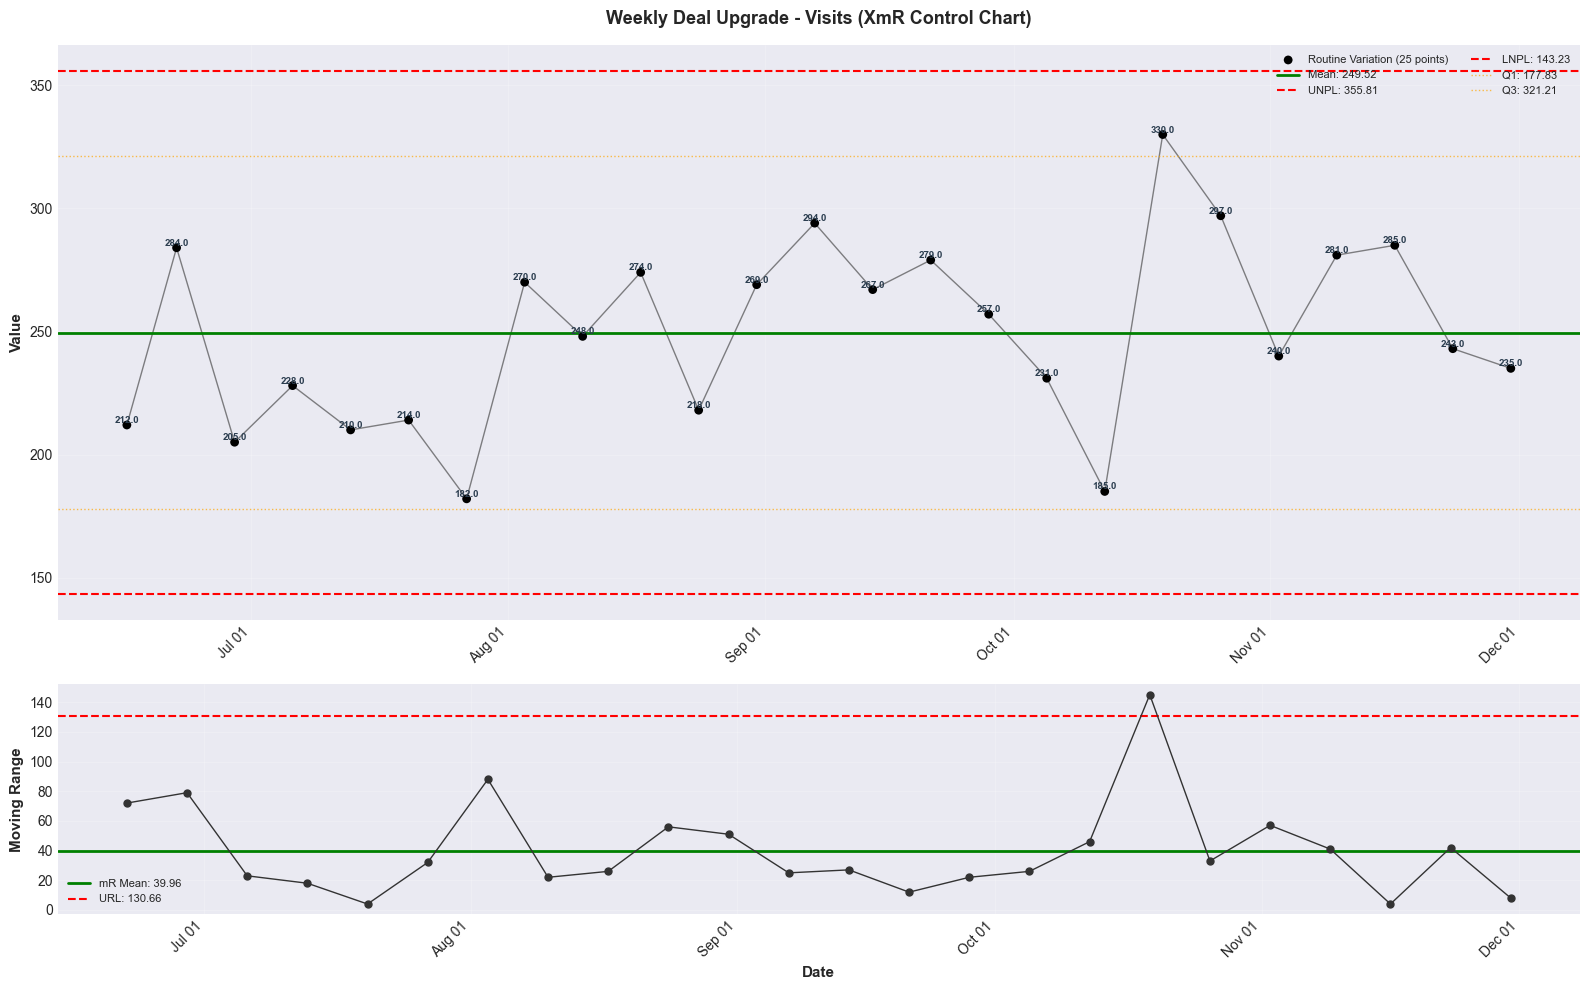

In [25]:
print("\n" + "=" * 70)
print("GENERATING WEEKLY CHARTS - VISITS")
print("=" * 70 + "\n")

# Weekly Visits Chart (XmR Control Chart)
plot_xmr_from_csv(
    csv_path='../outputs/deal_upgrade/weekly_deal_upgrade.csv',
    date_col='Date Range',
    value_col='Visits',
    start_date=analysis_start,
    end_date=analysis_end,
    output_path=f'{viz_weekly_dir}/weekly_visits.png',
    chart_title='Weekly Deal Upgrade - Visits (XmR Control Chart)'
)

### Generate Weekly Charts - Conversion Rate


GENERATING WEEKLY CHARTS - CONVERSION RATE

✓ Loaded 26 rows from weekly_deal_upgrade.csv
✓ Filtered to dates >= 2025-01-01 00:00:00
✓ Filtered to dates <= 2025-12-06 00:00:00
✓ Analyzing 25 data points
✓ Chart saved to: ../visualizations/deal_upgrade_weekly/weekly_conversion_rate.png

XmR CHART STATISTICS
Mean: 29.03
UNPL: 38.78
LNPL: 19.28
Q1: 22.45, Q3: 35.60
Moving Range Mean: 3.66
URL (mR): 11.98

Rule Violations Detected:
  Rule 1 (Process Limit): 1 points
  Rule 2 (Quartile): 5 points
  Rule 3 (Runs of 8): 8 points
  Routine Variation: 16 points



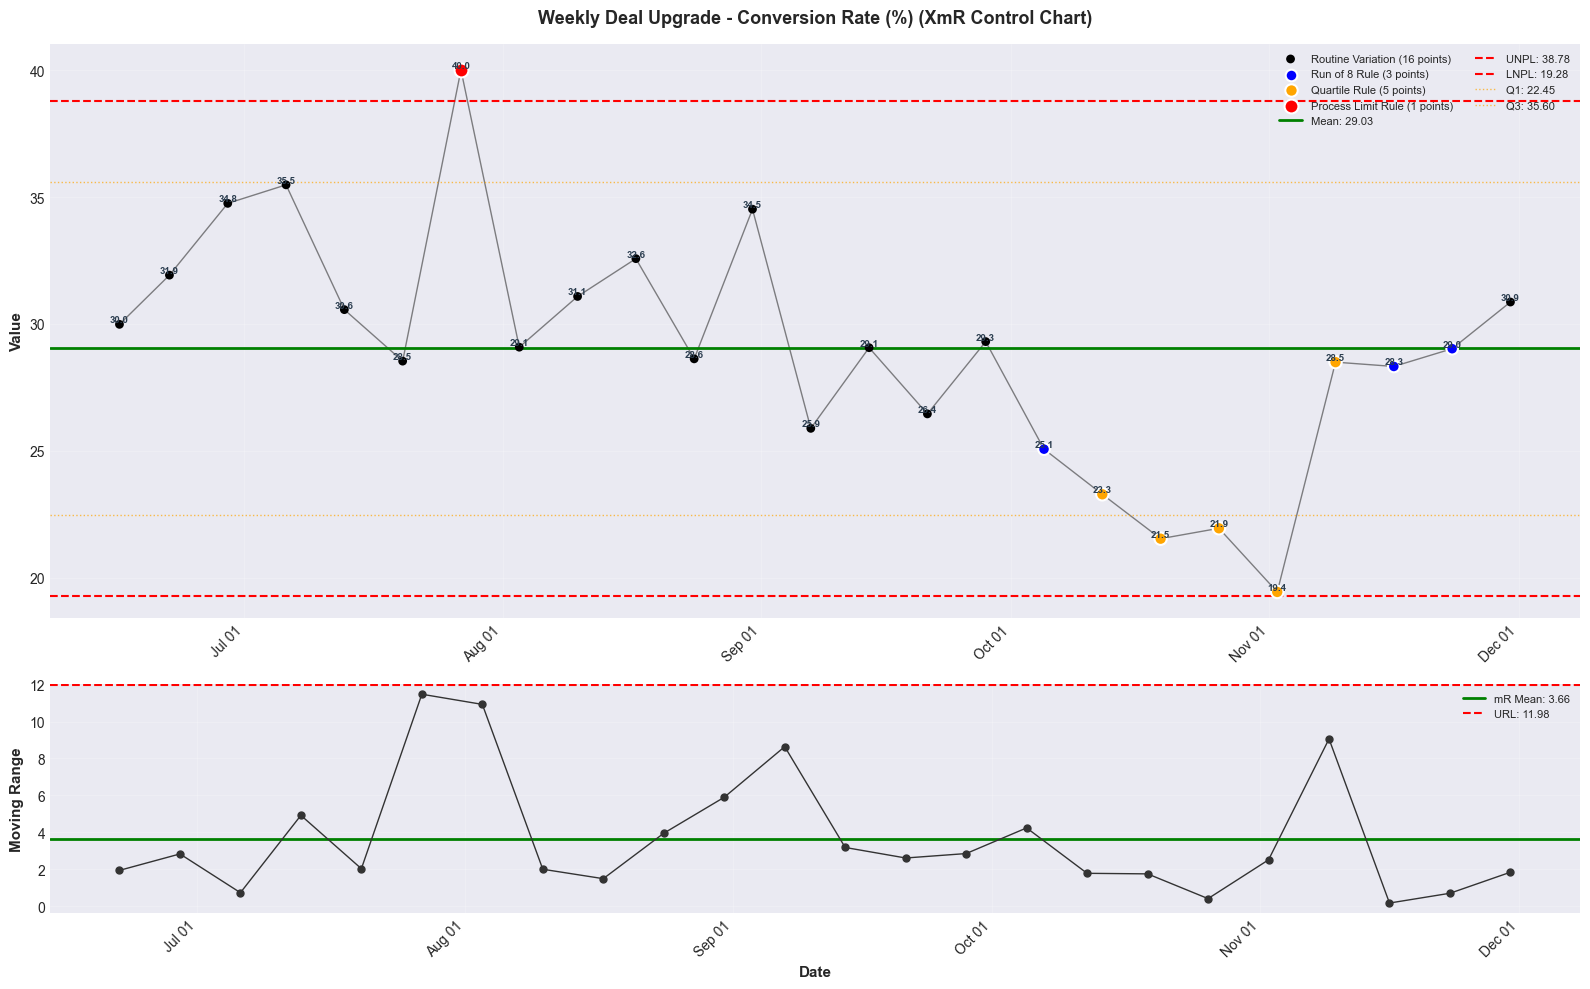

In [26]:
print("\n" + "=" * 70)
print("GENERATING WEEKLY CHARTS - CONVERSION RATE")
print("=" * 70 + "\n")

# Weekly Conversion Rate Chart (XmR Control Chart)
plot_xmr_from_csv(
    csv_path='../outputs/deal_upgrade/weekly_deal_upgrade.csv',
    date_col='Date Range',
    value_col='Conversion Rate',
    start_date=analysis_start,
    end_date=analysis_end,
    output_path=f'{viz_weekly_dir}/weekly_conversion_rate.png',
    chart_title='Weekly Deal Upgrade - Conversion Rate (%) (XmR Control Chart)'
)

### Generate Monthly Charts - Visits


GENERATING MONTHLY CHARTS - VISITS

✓ Loaded 7 monthly records
✓ Filtered to dates >= 2025-01-01
✓ Filtered to dates <= 2025-12-06
⚠️ Excluded 1 records from incomplete current month (December 2025)
✓ Visualizing 6 complete months
✓ Target line added: 1200.00
✓ Chart saved to: ../visualizations/deal_upgrade_monthly/monthly_visits.png

MONTHLY PERFORMANCE SUMMARY: Visits
Total Complete Months Analyzed: 6
Latest Complete Month: November 2025
Latest Month Value: 1071.00
Target: 1200.00
Gap to Target: -129.00

Month-over-Month Changes:
  Latest MoM Change: -8.07%
  Average MoM Change: 18.89%

Best Month: Sep 2025 (1224.00)
Worst Month: Jun 2025 (534.00)



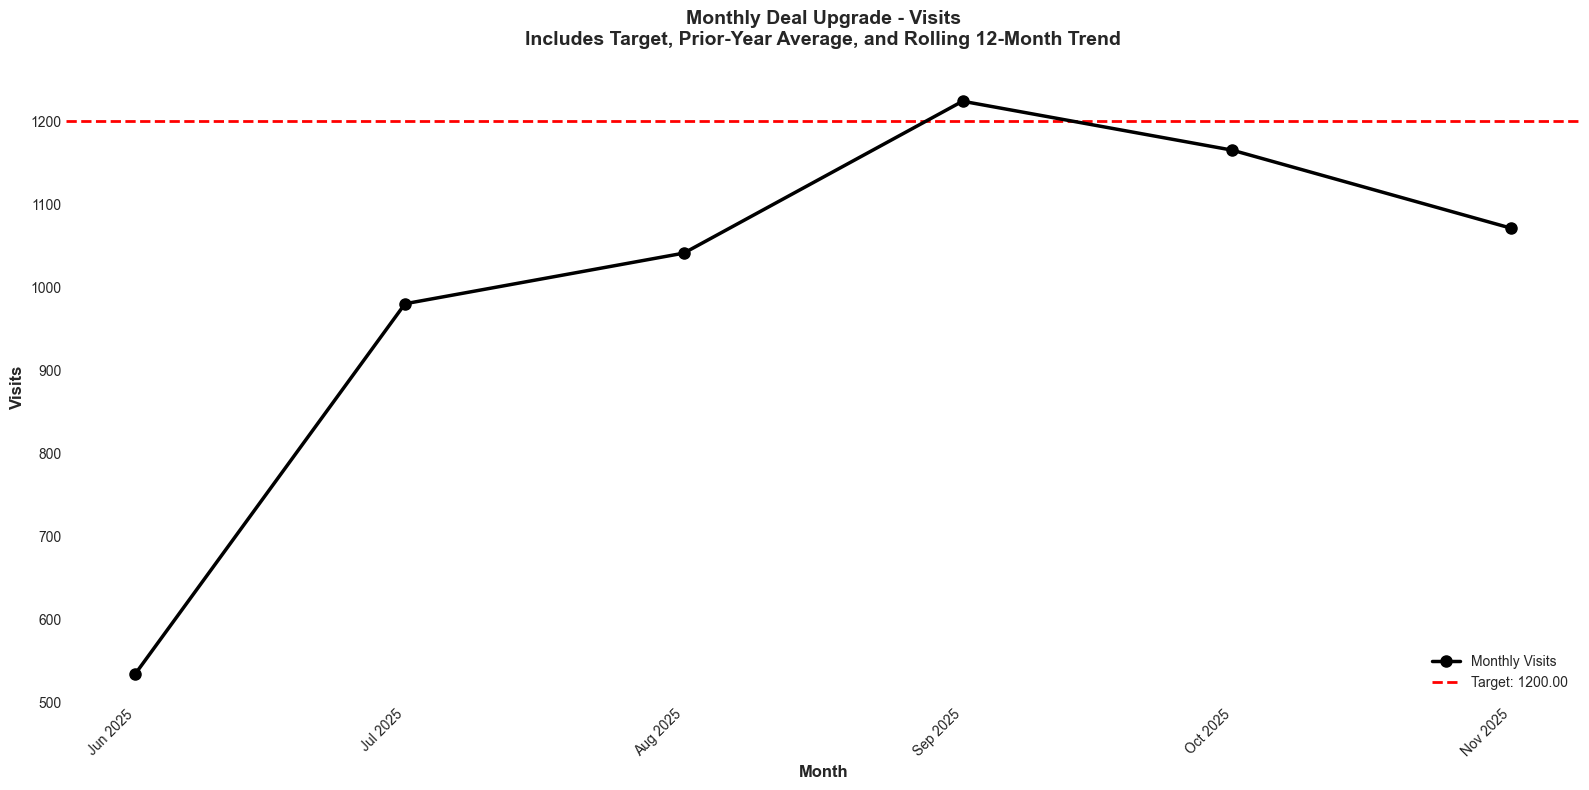

In [27]:
print("\n" + "=" * 70)
print("GENERATING MONTHLY CHARTS - VISITS")
print("=" * 70 + "\n")

# Monthly Visits Chart
create_monthly_chart(
    csv_path='../outputs/deal_upgrade/monthly_deal_upgrade.csv',
    date_col='Month',
    metric_col='Visits',
    target_value=monthly_du_visits_target,
    output_path=f'{viz_monthly_dir}/monthly_visits.png',
    chart_title='Monthly Deal Upgrade - Visits',
    metric_name='Visits',
    start_date=analysis_start,
    end_date=analysis_end
)

### Generate Monthly Charts - Conversion Rate


GENERATING MONTHLY CHARTS - CONVERSION RATE

✓ Loaded 7 monthly records
✓ Filtered to dates >= 2025-01-01
✓ Filtered to dates <= 2025-12-06
⚠️ Excluded 1 records from incomplete current month (December 2025)
✓ Visualizing 6 complete months
✓ Target line added: nan
✓ Chart saved to: ../visualizations/deal_upgrade_monthly/monthly_conversion_rate.png

MONTHLY PERFORMANCE SUMMARY: Conversion Rate (%)
Total Complete Months Analyzed: 6
Latest Complete Month: November 2025
Latest Month Value: 26.23
Target: nan
Gap to Target: +nan

Month-over-Month Changes:
  Latest MoM Change: +5.51%
  Average MoM Change: -2.90%

Best Month: Aug 2025 (33.35)
Worst Month: Oct 2025 (24.86)



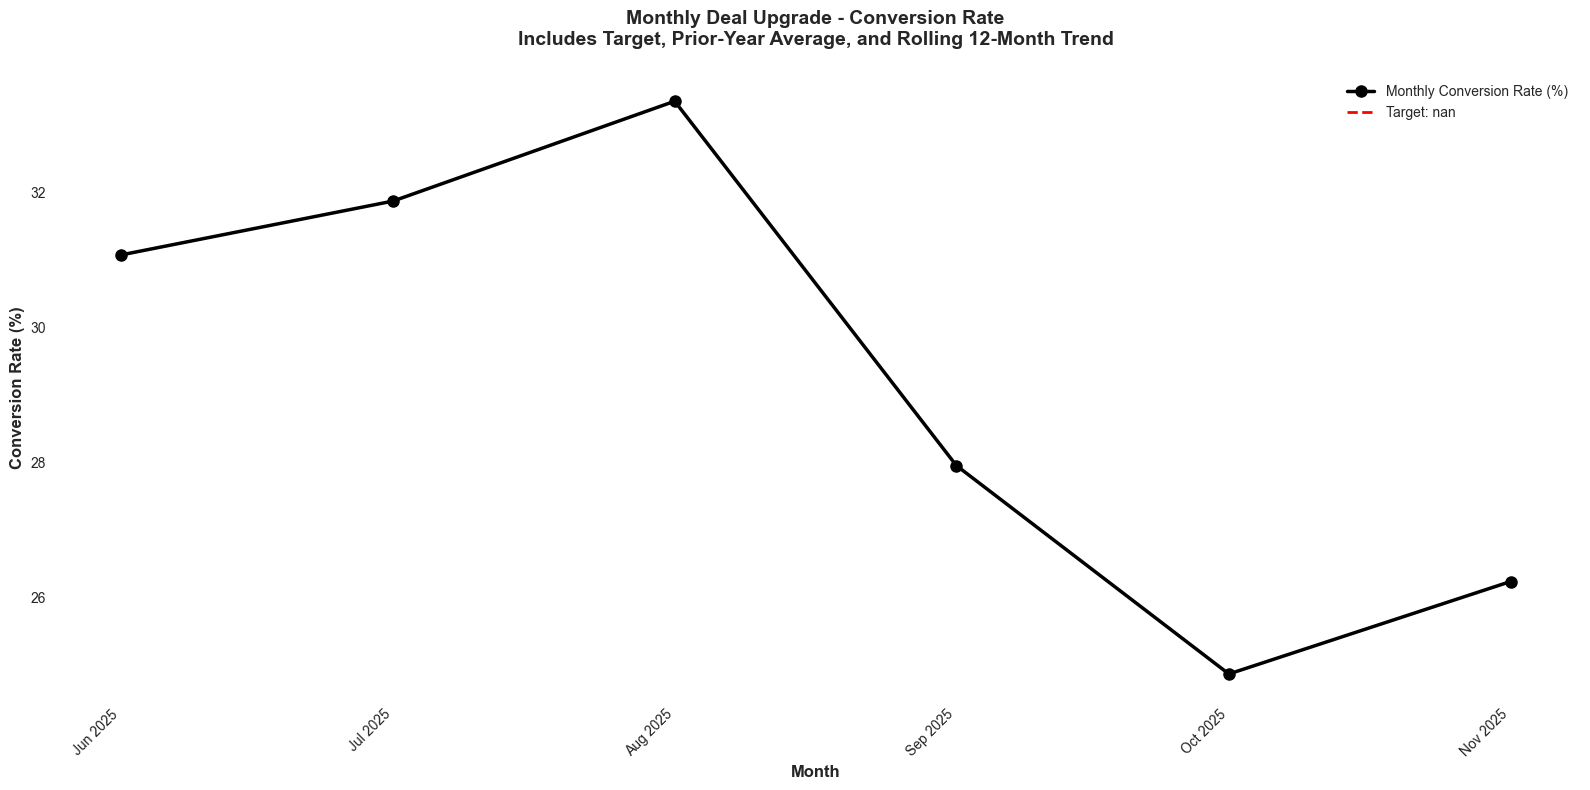

In [28]:
print("\n" + "=" * 70)
print("GENERATING MONTHLY CHARTS - CONVERSION RATE")
print("=" * 70 + "\n")

# Monthly Conversion Rate Chart
create_monthly_chart(
    csv_path='../outputs/deal_upgrade/monthly_deal_upgrade.csv',
    date_col='Month',
    metric_col='Conversion Rate',
    target_value=monthly_du_conversion_target,
    output_path=f'{viz_monthly_dir}/monthly_conversion_rate.png',
    chart_title='Monthly Deal Upgrade - Conversion Rate',
    metric_name='Conversion Rate (%)',
    start_date=analysis_start,
    end_date=analysis_end
)

### Generate Quarterly Charts - Visits


GENERATING QUARTERLY CHARTS - VISITS

✓ Loaded 3 quarterly records
✓ Visualizing 3 quarters
✓ Target line added: 2500.00
✓ Chart saved to: ../visualizations/deal_upgrade_quarterly/quarterly_visits.png

QUARTERLY PERFORMANCE SUMMARY: Visits
Total Quarters Analyzed: 3
Latest Quarter: 2025Q4
Date Range: 10/01/2025 - 12/08/2025
Latest Quarter Value: 2469.00
Target: 2500.00
Gap to Target: -31.00

Latest QoQ Change: -23.91%

Best Quarter: 2025Q3 (3245.00)
Worst Quarter: 2025Q2 (534.00)



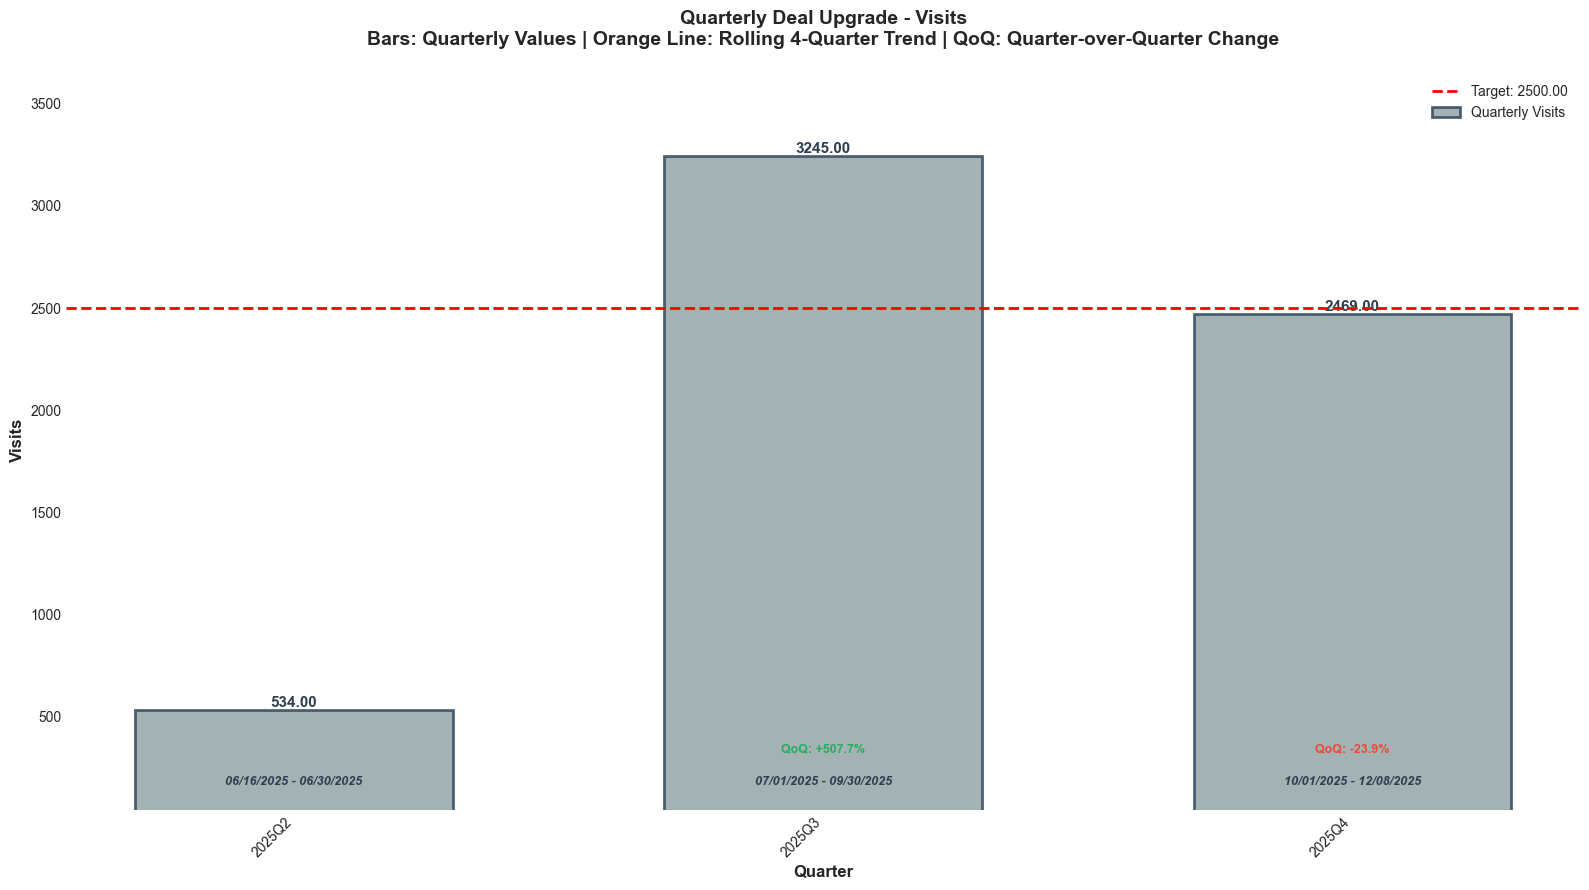

In [29]:
print("\n" + "=" * 70)
print("GENERATING QUARTERLY CHARTS - VISITS")
print("=" * 70 + "\n")

# Quarterly Visits Chart
create_quarterly_chart(
    csv_path='../outputs/deal_upgrade/quarterly_deal_upgrade.csv',
    metric_col='Visits',
    target_value=quarterly_du_visits_target,
    output_path=f'{viz_quarterly_dir}/quarterly_visits.png',
    chart_title='Quarterly Deal Upgrade - Visits',
    metric_name='Visits'
)

### Generate Quarterly Charts - Conversion Rate


GENERATING QUARTERLY CHARTS - CONVERSION RATE

✓ Loaded 3 quarterly records
✓ Visualizing 3 quarters
✓ Target line added: nan
✓ Chart saved to: ../visualizations/deal_upgrade_quarterly/quarterly_conversion_rate.png

QUARTERLY PERFORMANCE SUMMARY: Conversion Rate (%)
Total Quarters Analyzed: 3
Latest Quarter: 2025Q4
Date Range: 10/01/2025 - 12/08/2025
Latest Quarter Value: 26.14
Target: nan
Gap to Target: +nan

Latest QoQ Change: -15.92%

Best Quarter: 2025Q3 (31.09)
Worst Quarter: 2025Q4 (26.14)



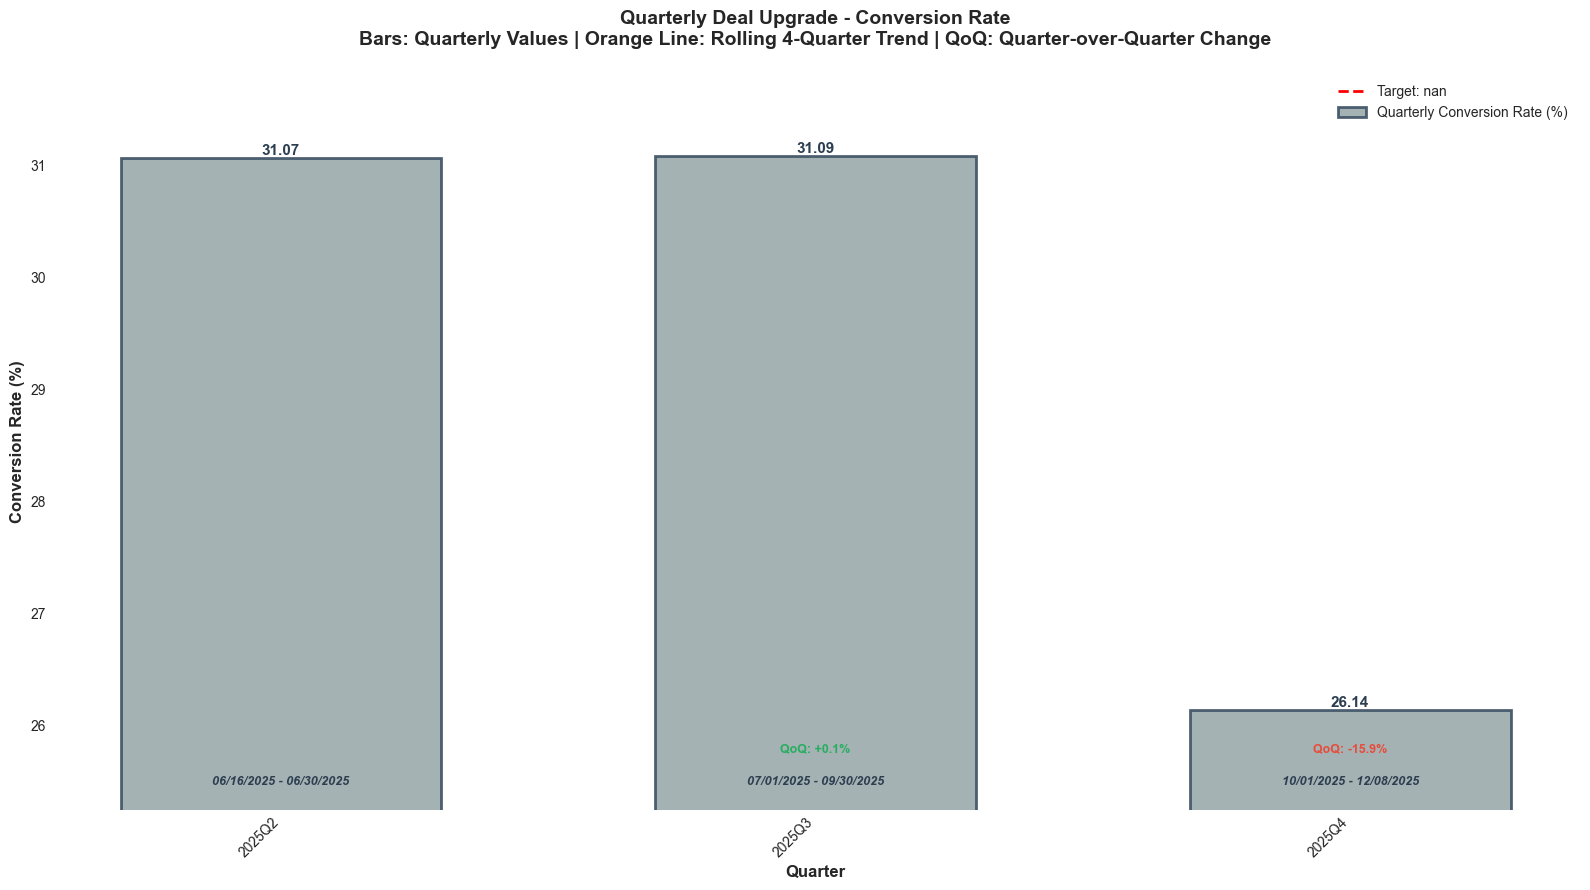

In [30]:
print("\n" + "=" * 70)
print("GENERATING QUARTERLY CHARTS - CONVERSION RATE")
print("=" * 70 + "\n")

# Quarterly Conversion Rate Chart
create_quarterly_chart(
    csv_path='../outputs/deal_upgrade/quarterly_deal_upgrade.csv',
    metric_col='Conversion Rate',
    target_value=quarterly_du_conversion_target,
    output_path=f'{viz_quarterly_dir}/quarterly_conversion_rate.png',
    chart_title='Quarterly Deal Upgrade - Conversion Rate',
    metric_name='Conversion Rate (%)'
)

### Generate Annual Charts - Visits


GENERATING ANNUAL CHARTS - VISITS

✓ Loaded 1 annual records
✓ Visualizing 1 years
✓ Target line added: 3000.00
✓ Chart saved to: ../visualizations/deal_upgrade_annual/annual_visits.png

ANNUAL PERFORMANCE SUMMARY: Visits
Total Years: 1
Years: 2025 to 2025
Incomplete Years (YTD): 2025

Latest Year (2025) Value: 6248.00
Date Range: 06/16/2025 - 12/08/2025
Target: 3000.00
Gap to Target: +3248.00

Best Year: 2025 (6248.00)
Worst Year: 2025 (6248.00)



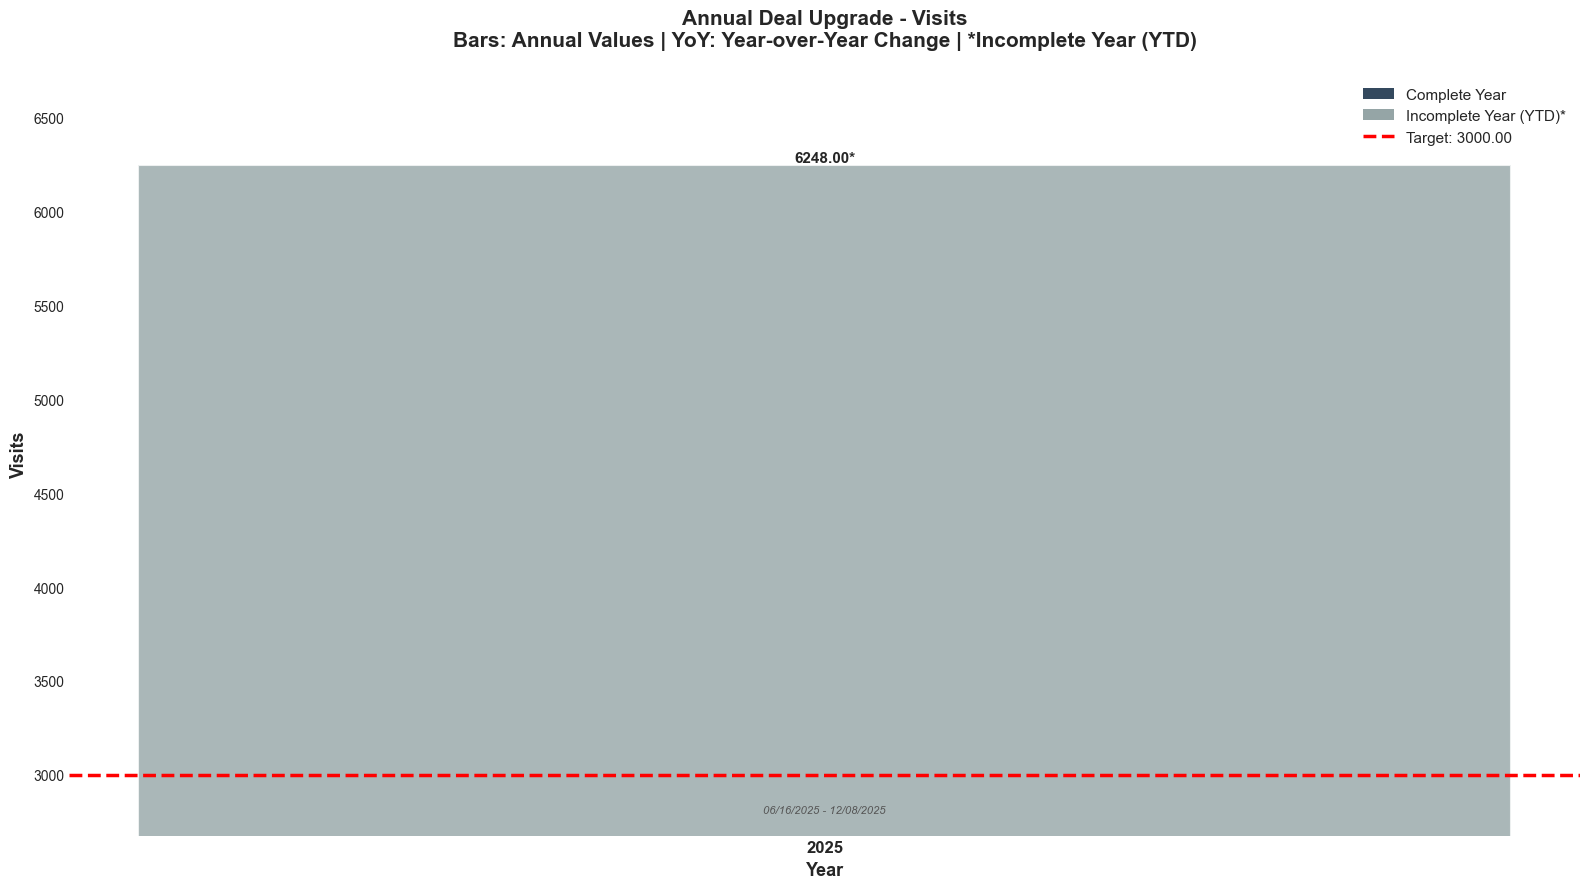

In [31]:
print("\n" + "=" * 70)
print("GENERATING ANNUAL CHARTS - VISITS")
print("=" * 70 + "\n")

# Annual Visits Chart
create_annual_chart(
    csv_path='../outputs/deal_upgrade/annual_deal_upgrade.csv',
    metric_col='Visits',
    target_value=annual_du_visits_target,
    output_path=f'{viz_annual_dir}/annual_visits.png',
    chart_title='Annual Deal Upgrade - Visits',
    metric_name='Visits'
)

### Generate Annual Charts - Conversion Rate


GENERATING ANNUAL CHARTS - CONVERSION RATE

✓ Loaded 1 annual records
✓ Visualizing 1 years
✓ Target line added: nan
✓ Chart saved to: ../visualizations/deal_upgrade_annual/annual_conversion_rate.png

ANNUAL PERFORMANCE SUMMARY: Conversion Rate (%)
Total Years: 1
Years: 2025 to 2025
Incomplete Years (YTD): 2025

Latest Year (2025) Value: 29.15
Date Range: 06/16/2025 - 12/08/2025
Target: nan
Gap to Target: +nan

Best Year: 2025 (29.15)
Worst Year: 2025 (29.15)



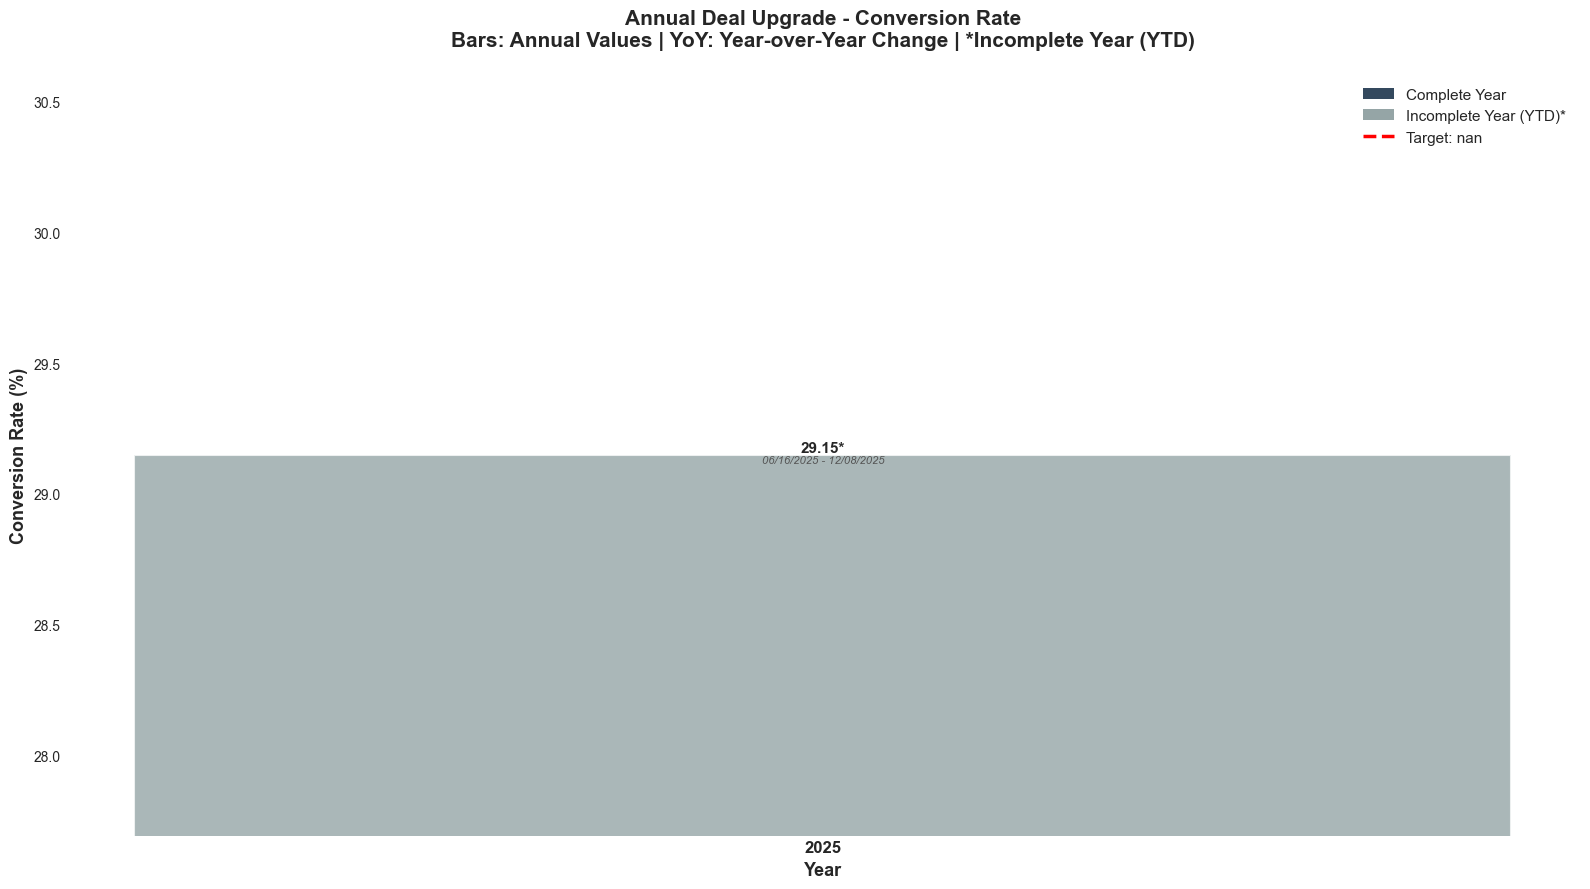

In [32]:
print("\n" + "=" * 70)
print("GENERATING ANNUAL CHARTS - CONVERSION RATE")
print("=" * 70 + "\n")

# Annual Conversion Rate Chart
create_annual_chart(
    csv_path='../outputs/deal_upgrade/annual_deal_upgrade.csv',
    metric_col='Conversion Rate',
    target_value=annual_du_conversion_target,
    output_path=f'{viz_annual_dir}/annual_conversion_rate.png',
    chart_title='Annual Deal Upgrade - Conversion Rate',
    metric_name='Conversion Rate (%)'
)

### Visualization Summary

In [33]:
print("\n" + "=" * 70)
print("VISUALIZATION GENERATION COMPLETE")
print("=" * 70)

# Count generated files
weekly_charts = len([f for f in os.listdir(viz_weekly_dir) if f.endswith('.png')])
monthly_charts = len([f for f in os.listdir(viz_monthly_dir) if f.endswith('.png')])
quarterly_charts = len([f for f in os.listdir(viz_quarterly_dir) if f.endswith('.png')])
annual_charts = len([f for f in os.listdir(viz_annual_dir) if f.endswith('.png')])

total_charts = weekly_charts + monthly_charts + quarterly_charts + annual_charts

print(f"\n📊 Charts Generated Summary:")
print(f"  Weekly Charts: {weekly_charts} (XmR Control Charts)")
print(f"  Monthly Charts: {monthly_charts} (Trend + Target)")
print(f"  Quarterly Charts: {quarterly_charts} (Bars + Trend + Target)")
print(f"  Annual Charts: {annual_charts} (Bars + Trend + Target)")
print(f"\n  Total Charts Generated: {total_charts}")

print(f"\n📁 Visualization Directories:")
print(f"  Weekly: {viz_weekly_dir}")
print(f"  Monthly: {viz_monthly_dir}")
print(f"  Quarterly: {viz_quarterly_dir}")
print(f"  Annual: {viz_annual_dir}")

print("\n" + "=" * 70)
print("✓ All Deal Upgrade charts generated successfully!")
print("=" * 70 + "\n")


VISUALIZATION GENERATION COMPLETE

📊 Charts Generated Summary:
  Weekly Charts: 2 (XmR Control Charts)
  Monthly Charts: 2 (Trend + Target)
  Quarterly Charts: 2 (Bars + Trend + Target)
  Annual Charts: 2 (Bars + Trend + Target)

  Total Charts Generated: 8

📁 Visualization Directories:
  Weekly: ../visualizations/deal_upgrade_weekly
  Monthly: ../visualizations/deal_upgrade_monthly
  Quarterly: ../visualizations/deal_upgrade_quarterly
  Annual: ../visualizations/deal_upgrade_annual

✓ All Deal Upgrade charts generated successfully!



### List All Generated Charts

In [34]:
# Display all generated chart files
print("\n" + "=" * 70)
print("GENERATED CHART FILES")
print("=" * 70 + "\n")

print("WEEKLY CHARTS (XmR Control Charts):")
print("-" * 70)
for file in sorted(os.listdir(viz_weekly_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_weekly_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<40} ({file_size:.1f} KB)")

print("\nMONTHLY CHARTS (Trend + Target + MoM%):")
print("-" * 70)
for file in sorted(os.listdir(viz_monthly_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_monthly_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<40} ({file_size:.1f} KB)")

print("\nQUARTERLY CHARTS (Bars + Trend + Target + QoQ%):")
print("-" * 70)
for file in sorted(os.listdir(viz_quarterly_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_quarterly_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<40} ({file_size:.1f} KB)")

print("\nANNUAL CHARTS (Bars + Trend + Target + YoY%):")
print("-" * 70)
for file in sorted(os.listdir(viz_annual_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_annual_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<40} ({file_size:.1f} KB)")

print("\n" + "=" * 70)


GENERATED CHART FILES

WEEKLY CHARTS (XmR Control Charts):
----------------------------------------------------------------------
  • weekly_conversion_rate.png               (518.4 KB)
  • weekly_visits.png                        (499.9 KB)

MONTHLY CHARTS (Trend + Target + MoM%):
----------------------------------------------------------------------
  • monthly_conversion_rate.png              (257.4 KB)
  • monthly_visits.png                       (242.0 KB)

QUARTERLY CHARTS (Bars + Trend + Target + QoQ%):
----------------------------------------------------------------------
  • quarterly_conversion_rate.png            (203.9 KB)
  • quarterly_visits.png                     (205.6 KB)

ANNUAL CHARTS (Bars + Trend + Target + YoY%):
----------------------------------------------------------------------
  • annual_conversion_rate.png               (187.5 KB)
  • annual_visits.png                        (185.7 KB)



#

## CUSTOM DATE RANGE ANALYSIS

### Load Custom Date Range Parameters

In [35]:
# Load analysis reference dates from CSV
ref_dates_path = '../analysis_ref_date.csv'

# Check if file exists
if not os.path.exists(ref_dates_path):
    print(f"❌ Error: File not found at {ref_dates_path}")
    custom_start = None
    custom_end = None
else:
    # Load reference dates
    ref_dates = pd.read_csv(ref_dates_path, header=None)
    
    # Parse custom date range
    custom_start = None
    custom_end = None
    
    for idx, row in ref_dates.iterrows():
        if row[0] == 'Custom Start Date':
            try:
                custom_start = pd.to_datetime(row[1])
            except:
                custom_start = None
        elif row[0] == 'Custom End Date':
            try:
                custom_end = pd.to_datetime(row[1])
            except:
                custom_end = None
    
    print(f"Custom Date Range:")
    print(f"  Start: {custom_start if custom_start else 'Not specified'}")
    print(f"  End: {custom_end if custom_end else 'Not specified'}")
    
    if custom_start and custom_end:
        date_range_days = (custom_end - custom_start).days + 1
        print(f"  Duration: {date_range_days} days")
    else:
        print("\n⚠️ Custom date range not properly specified in analysis_ref_date.csv")

Custom Date Range:
  Start: 2025-11-01 00:00:00
  End: 2025-11-28 00:00:00
  Duration: 28 days


### Generate Custom Date Range Aggregated Data

In [36]:
print("\n" + "="*70)
print("CUSTOM DATE RANGE AGGREGATION (WITH PREVIOUS PERIOD)")
print("="*70 + "\n")

if custom_start and custom_end:
    # Calculate previous period dates - shift back by ONE MONTH, keeping same day-of-month
    from dateutil.relativedelta import relativedelta
    
    prev_start = custom_start - relativedelta(months=1)
    prev_end = custom_end - relativedelta(months=1)
    
    # Calculate duration for display
    date_range_duration = (custom_end - custom_start).days + 1
    
    print(f"Current Period: {custom_start.strftime('%m/%d/%Y')} - {custom_end.strftime('%m/%d/%Y')} ({date_range_duration} days)")
    print(f"Previous Period: {prev_start.strftime('%m/%d/%Y')} - {prev_end.strftime('%m/%d/%Y')} ({date_range_duration} days)\n")
    
    # Work with blended daily data for filtering
    df_custom_prep = df_blended_daily.copy()
    
    # Remove % sign from rates for calculation
    df_custom_prep['Bounce Rate'] = df_custom_prep['Bounce Rate'].str.rstrip('%').astype(float)
    df_custom_prep['Conversion Rate'] = df_custom_prep['Conversion Rate'].str.rstrip('%').astype(float)
    
    # Convert Date to datetime
    df_custom_prep['Date'] = pd.to_datetime(df_custom_prep['Date'])
    
    # Filter data for CURRENT custom date range
    df_custom_filtered = df_custom_prep[
        (df_custom_prep['Date'] >= custom_start) & 
        (df_custom_prep['Date'] <= custom_end)
    ].copy()
    
    # Filter data for PREVIOUS custom date range
    df_prev_filtered = df_custom_prep[
        (df_custom_prep['Date'] >= prev_start) & 
        (df_custom_prep['Date'] <= prev_end)
    ].copy()
    
    # Create empty list to store rows
    custom_rows = []
    
    # Process CURRENT period
    if len(df_custom_filtered) > 0:
        # Calculate the actual start and end dates from filtered data
        actual_start = df_custom_filtered['Date'].min()
        actual_end = df_custom_filtered['Date'].max()
        
        # Aggregate ALL the filtered data
        total_pageviews = df_custom_filtered['Pageviews'].sum()
        total_visits = df_custom_filtered['Visits'].sum()
        avg_duration = df_custom_filtered['Avg Duration'].mean()
        avg_bounce_rate = df_custom_filtered['Bounce Rate'].mean()
        total_events = df_custom_filtered['Events'].sum()
        
        # Calculate conversion rate as AVERAGE of daily conversion rates (not Events/Visits)
        avg_conversion_rate = df_custom_filtered['Conversion Rate'].mean()
        
        current_row = {
            'Date Range': f"{actual_start.strftime('%m/%d/%Y')} - {actual_end.strftime('%m/%d/%Y')}",
            'Pageviews': int(total_pageviews),
            'Visits': int(total_visits),
            'Avg Duration': round(avg_duration, 2),
            'Bounce Rate': f"{round(avg_bounce_rate, 2)}%",
            'Events': int(total_events),
            'Conversion Rate': f"{round(avg_conversion_rate, 2)}%"
        }
        custom_rows.append(current_row)
        
        print(f"✅ Current period data found: {len(df_custom_filtered)} daily records")
        print(f"   Total Pageviews: {total_pageviews:,}")
        print(f"   Total Visits: {total_visits:,}")
        print(f"   Total Events: {total_events:,}")
        print(f"   Avg Conversion Rate: {avg_conversion_rate:.2f}%")
        
    else:
        print(f"⚠️ No data for current period: {custom_start.strftime('%m/%d/%Y')} - {custom_end.strftime('%m/%d/%Y')}")
    
    # Process PREVIOUS period
    if len(df_prev_filtered) > 0:
        # Calculate the actual start and end dates from filtered data
        actual_start = df_prev_filtered['Date'].min()
        actual_end = df_prev_filtered['Date'].max()
        
        # Aggregate ALL the filtered data
        total_pageviews = df_prev_filtered['Pageviews'].sum()
        total_visits = df_prev_filtered['Visits'].sum()
        avg_duration = df_prev_filtered['Avg Duration'].mean()
        avg_bounce_rate = df_prev_filtered['Bounce Rate'].mean()
        total_events = df_prev_filtered['Events'].sum()
        
        # Calculate conversion rate as AVERAGE of daily conversion rates (not Events/Visits)
        avg_conversion_rate = df_prev_filtered['Conversion Rate'].mean()
        
        prev_row = {
            'Date Range': f"{actual_start.strftime('%m/%d/%Y')} - {actual_end.strftime('%m/%d/%Y')}",
            'Pageviews': int(total_pageviews),
            'Visits': int(total_visits),
            'Avg Duration': round(avg_duration, 2),
            'Bounce Rate': f"{round(avg_bounce_rate, 2)}%",
            'Events': int(total_events),
            'Conversion Rate': f"{round(avg_conversion_rate, 2)}%"
        }
        custom_rows.append(prev_row)
        
        print(f"✅ Previous period data found: {len(df_prev_filtered)} daily records")
        print(f"   Total Pageviews: {total_pageviews:,}")
        print(f"   Total Visits: {total_visits:,}")
        print(f"   Total Events: {total_events:,}")
        print(f"   Avg Conversion Rate: {avg_conversion_rate:.2f}%")
        
    else:
        print(f"⚠️ No data for previous period: {prev_start.strftime('%m/%d/%Y')} - {prev_end.strftime('%m/%d/%Y')}")
    
    # Create final dataframe
    if len(custom_rows) > 0:
        df_custom = pd.DataFrame(custom_rows)
        
        # Display the results
        print("\n" + "="*70)
        print("Custom Date Range Aggregated Data (with Previous Period):")
        print("="*70)
        display(df_custom)
        
    else:
        print("\n⚠️ No data available for either current or previous period")
        df_custom = None
        
else:
    print("❌ Cannot generate custom analysis - dates not properly specified")
    print("   Please check Custom Start Date and Custom End Date in analysis_ref_date.csv")
    df_custom = None

print("\n" + "="*70)


CUSTOM DATE RANGE AGGREGATION (WITH PREVIOUS PERIOD)

Current Period: 11/01/2025 - 11/28/2025 (28 days)
Previous Period: 10/01/2025 - 10/28/2025 (28 days)

✅ Current period data found: 28 daily records
   Total Pageviews: 1,244
   Total Visits: 1,041
   Total Events: 206
   Avg Conversion Rate: 24.73%
✅ Previous period data found: 28 daily records
   Total Pageviews: 1,171
   Total Visits: 1,008
   Total Events: 186
   Avg Conversion Rate: 25.14%

Custom Date Range Aggregated Data (with Previous Period):


,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate,Events,Conversion Rate
0,11/01/2025 - 11/28/2025,1244,1041,180.34,86.24%,206,24.73%
1,10/01/2025 - 10/28/2025,1171,1008,138.82,89.12%,186,25.14%


### Save Custom Date Range Data

In [37]:
if df_custom is not None and len(df_custom) > 0:
    # Save to CSV
    custom_path = os.path.join(output_dir, 'custom_deal_upgrade.csv')
    df_custom.to_csv(custom_path, index=False)
    
    print("\n" + "="*70)
    print("CUSTOM DATE RANGE ANALYSIS - COMPLETE")
    print("="*70)
    
    print(f"\n✅ OUTPUT CREATED:")
    print(f"  - custom_deal_upgrade.csv")
    
    print(f"\n📁 Saved in:")
    print(f"  - {custom_path}")
    
    print(f"\n📊 File Details:")
    print(f"  - Shape: {df_custom.shape[0]} rows × {df_custom.shape[1]} columns")
    print(f"  - Date Range: {custom_start.strftime('%m/%d/%Y')} - {custom_end.strftime('%m/%d/%Y')}")
    print(f"  - Duration: {(custom_end - custom_start).days + 1} days")
    
    print(f"\n📈 Columns:")
    print(f"  - Date Range, Pageviews, Visits, Avg Duration")
    print(f"  - Bounce Rate, Events, Conversion Rate")
    
    print("\n" + "="*70)
else:
    print("\n⚠️ Custom analysis not saved - no data to save")
    print("   Check date range and data availability")


CUSTOM DATE RANGE ANALYSIS - COMPLETE

✅ OUTPUT CREATED:
  - custom_deal_upgrade.csv

📁 Saved in:
  - ../outputs/deal_upgrade/custom_deal_upgrade.csv

📊 File Details:
  - Shape: 2 rows × 7 columns
  - Date Range: 11/01/2025 - 11/28/2025
  - Duration: 28 days

📈 Columns:
  - Date Range, Pageviews, Visits, Avg Duration
  - Bounce Rate, Events, Conversion Rate



### Verification - Preview Custom Date Range File

In [38]:
if df_custom is not None and len(df_custom) > 0:
    print("Custom Date Range Data Preview:")
    print("="*70)
    display(df_custom)
    
    print(f"\n✓ Custom date range analysis completed successfully!")
    print(f"  File location: ../outputs/deal_upgrade/custom_deal_upgrade.csv")
else:
    print("⚠️ No custom data available to preview")

Custom Date Range Data Preview:


,Date Range,Pageviews,Visits,Avg Duration,Bounce Rate,Events,Conversion Rate
0,11/01/2025 - 11/28/2025,1244,1041,180.34,86.24%,206,24.73%
1,10/01/2025 - 10/28/2025,1171,1008,138.82,89.12%,186,25.14%



✓ Custom date range analysis completed successfully!
  File location: ../outputs/deal_upgrade/custom_deal_upgrade.csv
